# Step 2b — Advanced State Competitiveness Indicators

**Objective:** Build on Step 2 with competitiveness metrics — revealing not just what states trade and with whom, but how competitive they are structurally, how concentrated their product base is, and what their logistical profile looks like.

**Prerequisites:** Step 2 must have been run first. This notebook reuses `df_state` and other dataframes from that session, or re-queries them where needed.

This notebook covers:
1. Revealed Comparative Advantage (RCA) by State and SH2 Sector (2b.1)
2. Krugman Specialisation Index by State (2b.2)
3. Product Concentration Index (HHI) by State (2b.3)
4. Export Frequency — Number of Shipments by State (2b.4)
5. Export Frequency vs HHI: Does Product Concentration Predict How Often a State Trades? (2b.5)
6. Export Value Density by State — USD/kg (2b.6)
7. Logistics Profile Summary — Bulk vs High-Frequency Exporters (2b.7)
8. Regression Analysis — Shipment Size vs Export Value Density (2b.8)
9. Key Findings

## Setup

This section constructs the baseline dataset of exports and imports by state using the latest complete year of data (2025).  
Non-geographic records are excluded to ensure analytical consistency, and values are standardized for comparison across states.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data
MAX_YEAR = 2025

## Re-query state totals in case Step 2 session is not active
query_state_totals = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""
df_state = pd.read_sql(query_state_totals, engine)
## Remove non-geographic entries — these are not real states and distort all analyses
df_state = df_state[~df_state['state'].isin(['Não Declarada', 'Exterior'])]
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
print(f"State totals loaded: {len(df_state)} states")

Connected to database successfully
State totals loaded: 27 states


## 2b.1 — Revealed Comparative Advantage (RCA) by State and SH2 Sector
The RCA index measures whether a state exports a given sector more intensively than Brazil does nationally.

**Formula:** RCA = (State share in sector) / (National share in sector)

- RCA > 1 → the state has a comparative advantage in that sector
- RCA < 1 → the state is less specialised in that sector than the national average

Calculated at SH2 sector level for all states in MAX_YEAR (the most recent complete year).

### RCA Heatmap — Top 10 States and Top 10 Sectors

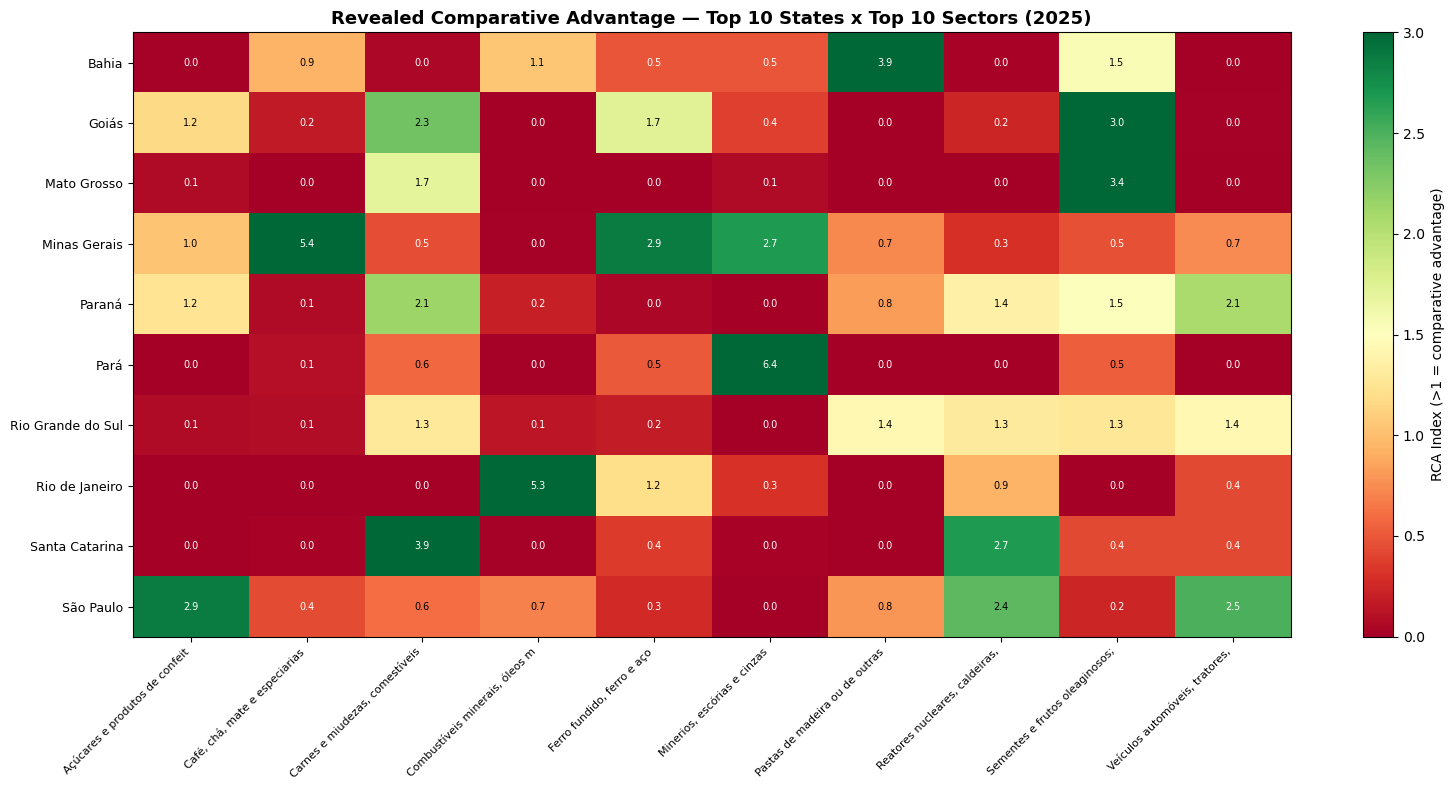


Top 5 sectors by RCA per state (2025) — sectors where RCA > 1 indicate comparative advantage

  São Paulo
    Aeronaves e aparelhos espaciais, e suas parte RCA=4.65  $4.54bn
    Estanho e suas obras                          RCA=4.41  $0.26bn
    Fibras sintéticas ou artificiais, descontínua RCA=4.18  $0.05bn
    Produtos para fotografia e cinematografia     RCA=4.07  $0.03bn
    Tapetes e outros revestimentos para pisos (pa RCA=4.01  $0.02bn

  Rio de Janeiro
    Combustíveis minerais, óleos minerais e produ RCA=5.30  $40.79bn
    Níquel e suas obras                           RCA=2.57  $0.02bn
    Embarcações e estruturas flutuantes           RCA=1.97  $0.02bn
    Obras de espartaria ou de cestaria            RCA=1.57  $0.00bn
    Borracha e suas obras                         RCA=1.26  $0.34bn

  Minas Gerais
    Zinco e suas obras                            RCA=7.32  $0.19bn
    Outros metais comuns; ceramais (cermets); obr RCA=6.96  $0.20bn
    Café, chá, mate e especiarias         

In [7]:
## Exports by state and SH2 sector
query_rca = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""
df_rca_raw = pd.read_sql(query_rca, engine)
## Remove non-geographic entries carried over from df_rca_raw
df_rca_raw = df_rca_raw[~df_rca_raw['state'].isin(['Não Declarada', 'Exterior'])]
## State total exports
state_totals = df_rca_raw.groupby('uf')['exports_usd'].sum().rename('state_total')
df_rca_raw   = df_rca_raw.join(state_totals, on='uf')
## National total exports per sector
national_sector = df_rca_raw.groupby('sector')['exports_usd'].sum().rename('national_sector')
df_rca_raw      = df_rca_raw.join(national_sector, on='sector')
## National total exports
national_total = df_rca_raw['exports_usd'].sum()
## RCA = (state_sector / state_total) / (national_sector / national_total)
df_rca_raw['state_sector_share']    = df_rca_raw['exports_usd']    / df_rca_raw['state_total']
df_rca_raw['national_sector_share'] = df_rca_raw['national_sector'] / national_total
df_rca_raw['rca'] = (df_rca_raw['state_sector_share'] / df_rca_raw['national_sector_share']).round(3)
## Focus on top 10 exporting states and top 10 sectors by national value
top10_states  = df_state.head(10)['state'].tolist()
top10_sectors = (
    df_rca_raw.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_rca_heat = df_rca_raw[
    df_rca_raw['state'].isin(top10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)
## Shorten sector labels for readability
df_rca_heat.columns = [str(c)[:30] for c in df_rca_heat.columns]
## Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat.columns)))
ax.set_xticklabels(df_rca_heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat.index)))
ax.set_yticklabels(df_rca_heat.index, fontsize=9)
## Annotate cells with RCA value
for i in range(len(df_rca_heat.index)):
    for j in range(len(df_rca_heat.columns)):
        val = df_rca_heat.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')
plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Top 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1_rca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
## Print top 5 RCA sectors per state
print(f"\nTop 5 sectors by RCA per state ({MAX_YEAR}) — sectors where RCA > 1 indicate comparative advantage")
for state in top10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

### Overview

The RCA results reveal a clear structural divide in Brazil's state-level export competitiveness. States in the Center-West and North show strong comparative advantages concentrated in agricultural commodities and mineral extraction respectively, while the Southeast leads in industrial and manufactured goods — particularly São Paulo in aerospace, vehicles and machinery, and Minas Gerais in coffee and iron ore. The South and Northeast are the most structurally diverse regions, with RCA values above 1 spanning both commodity and industrial sectors. The South's competitive strengths sit primarily in diversified agro-industrial goods — processed meats, grains and forestry products — while the Northeast spans the full spectrum from commodity monocultures in states like Piauí to emerging industrial competitiveness in semi-finished steel and vehicles.

However RCA measures relative specialisation rather than absolute scale — a state can show strong comparative advantage in a sector that represents a negligible share of national or global output. Many high-RCA sectors across states such as Paraná, Santa Catarina and Bahia are built on export values below \$0.10bn, reflecting niche or residual specialisations rather than structural industrial capacity. The cases where high RCA and material export value coincide — Rio de Janeiro in mineral fuels (\\$40.79bn, RCA 5.30), Pará in ores (\\$15.73bn, RCA 6.42), Minas Gerais in coffee (\\$11.29bn, RCA 5.45) and iron ore (\\$4.67bn, RCA 2.87), São Paulo in aerospace (\\$4.54bn, RCA 4.65), Mato Grosso in soybeans (\\$13.17bn, RCA 3.39), cotton (\\$3.13bn, RCA 7.11) and cereals (\\$4.67bn, RCA 5.67), and Rio Grande do Sul in tobacco (\\$3.05bn, RCA 14.45) — represent the clearest cases of genuine structural competitive advantage. Notably all of these are commodity or agro-processed sectors, reinforcing the finding from cell 2.13 that Brazil's export composition shifted from 56% manufactured goods in 1997 to 58.2% primary commodities by 2025.

---

### Interesting Observations

- Rio de Janeiro is the only state where a single sector dominates both RCA and absolute value simultaneously (\$40.79bn, RCA 5.30) — unique in the dataset
- Bahia's cocoa (RCA 20.44, \\$0.55bn) is the most economically meaningful high-RCA agro-processed sector outside the major commodity states
- The textile RCA cluster in Santa Catarina (four sectors above RCA 13, all below \\$0.06bn) is the clearest example of the small-denominator artefact problem in this dataset

> ⚠️ *Requires further investigation (Step 5): Do the high-RCA low-value sectors in Paraná, Santa Catarina and Rio Grande do Sul represent genuine emerging competitiveness or statistical artefacts of small national market shares?*
---
---


## 2b.2 — Krugman Specialisation Index by State

The Krugman Specialisation Index (KSI) measures how far each state's export mix deviates from Brazil's national average. A high KSI means the state exports a structurally different basket of goods from Brazil's overall mix — typically indicating heavy concentration in one or two sectors. A low KSI means the state mirrors the national mix closely — typically indicating a diversified export base that reflects the full breadth of Brazil's sectoral composition.

**Formula:** KSI = Σ |state_sector_share - national_sector_share| for all sectors

**Range:** 0 to 2, where:
- **0** — the state's export mix is identical to the national mix
- **> 1** — the state is highly specialised relative to Brazil as a whole
- **2** — the state's export mix shares no sectors with the national mix

A high KSI indicates a state exports a structurally distinct set of products relative to the national average. A low KSI indicates the state's export composition broadly mirrors Brazil's overall sectoral distribution.

***Note**: the KSI captures structural divergence from the national mix but does not indicate whether that divergence is driven by commodity concentration or industrial diversification — a state can score high by specialising in either soybeans or aerospace. The HHI in cell 2b.3 complements this by measuring within-state product concentration independently of the national benchmark.*

C:\Users\e_koh\AppData\Local\Temp\ipykernel_7932\2269547088.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())


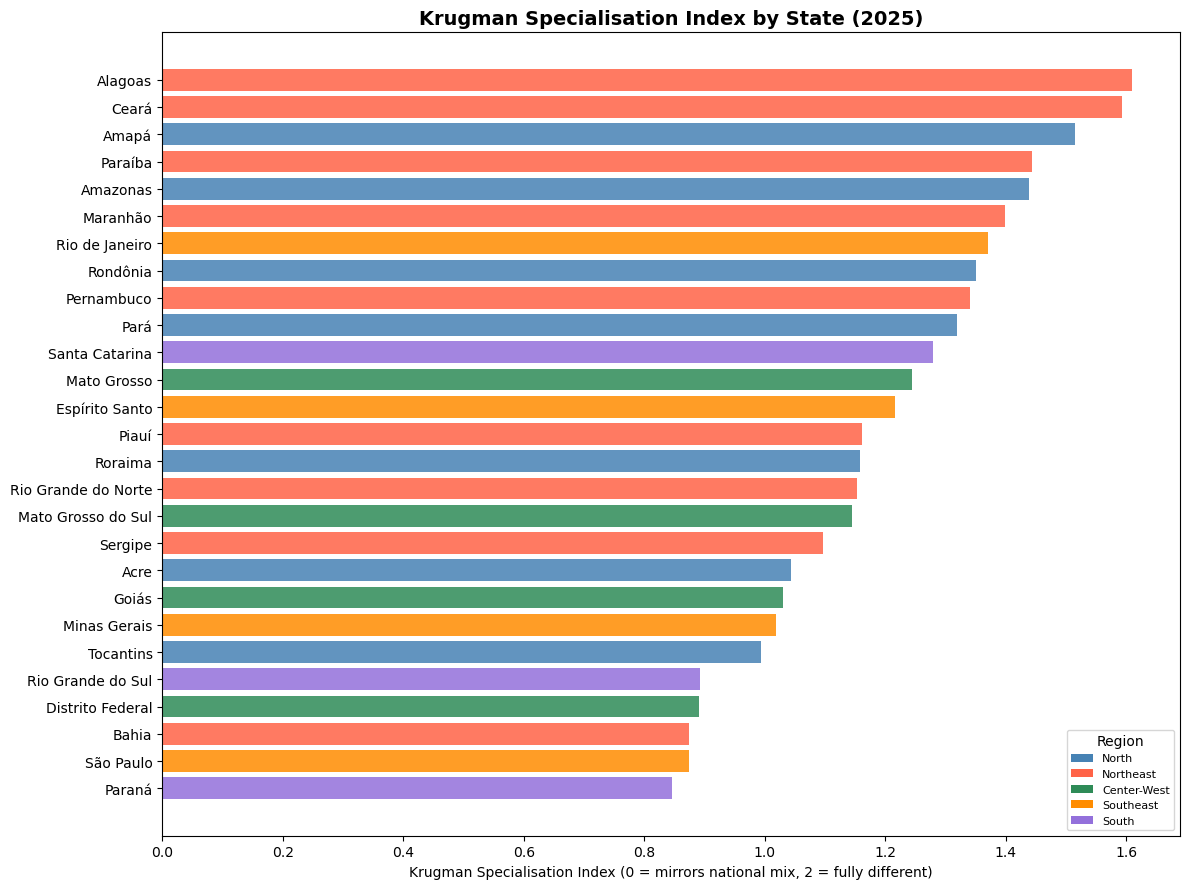


Krugman Specialisation Index by state (2025)
Higher KSI = more specialised / less diversified relative to national mix
              state      region  exports_usd_bn  krugman_idx
            Alagoas   Northeast            0.82       1.6084
              Ceará   Northeast            2.28       1.5934
              Amapá       North            0.14       1.5147
            Paraíba   Northeast            0.18       1.4431
           Amazonas       North            0.94       1.4380
           Maranhão   Northeast            5.02       1.3988
     Rio de Janeiro   Southeast           48.98       1.3696
           Rondônia       North            3.09       1.3509
         Pernambuco   Northeast            2.54       1.3401
               Pará       North           24.34       1.3181
     Santa Catarina       South           12.20       1.2783
        Mato Grosso Center-West           30.19       1.2439
     Espírito Santo   Southeast           10.51       1.2157
              Piauí   Nort

In [8]:
df_krugman = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())
    .reset_index()
    .rename(columns={0: 'krugman_idx'})
)
df_krugman['krugman_idx'] = df_krugman['krugman_idx'].round(4)
df_krugman = df_krugman.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_krugman['region'] = df_krugman['region'].map(region_name_map).fillna(df_krugman['region'])

df_krugman_plot = df_krugman.sort_values('krugman_idx', ascending=True)
## Colour by region
region_colors = {
    r: c for r, c in zip(
        df_krugman['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_krugman_plot['region'].map(region_colors).fillna('lightgray')
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_krugman_plot['state'], df_krugman_plot['krugman_idx'], color=bar_colors, alpha=0.85)
ax.set_title(f'Krugman Specialisation Index by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Krugman Specialisation Index (0 = mirrors national mix, 2 = fully different)')
## Region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b2_krugman.png', dpi=150)
plt.show()
print(f"\nKrugman Specialisation Index by state ({MAX_YEAR})")
print("Higher KSI = more specialised / less diversified relative to national mix")
print(df_krugman[['state', 'region', 'exports_usd_bn', 'krugman_idx']]
      .sort_values('krugman_idx', ascending=False)
      .to_string(index=False))

### Overview

**Range in this dataset: 0.85 (Paraná) to 1.61 (Alagoas)**

---

## Regional Pattern

| Region | Average KSI | Interpretation |
|---|---|---|
| Northeast | ~1.35 | Highest average specialisation — commodity and monoculture driven 
| North | ~1.30 | High specialisation — natural resource extraction |
| Southeast) | ~1.13 | Wide range — São Paulo pulls down, Rio de Janeiro pulls up |
| Center-West | ~1.10 | Moderate — agricultural with some diversification |
| South | ~1.01 | Closest to national average — most diversified region |

The Southern region's average KSI closest to 1.0 confirms what the RCA and HHI analyses suggested — the three Southern states (Paraná, Santa Catarina, Rio Grande do Sul) collectively produce the most nationally representative export basket.

---

## Observations

**Large exporters can still be highly specialised** — Rio de Janeiro (\\$48.98bn, KSI 1.36) and Mato Grosso (\\$30.19bn, KSI 1.25) demonstrate that high export value does not imply diversification. Both are structurally concentrated in single commodity clusters.

**Small exporters tend toward higher specialisation** — Alagoas (\\$0.82bn), Amapá (\\$0.14bn) and Paraíba (\\$0.18bn) all score above 1.40. Small states with one dominant product naturally deviate further from the national mix.

**São Paulo as the national benchmark** — with a KSI of 0.88 and the largest absolute export value (\\$71.39bn), São Paulo's export mix is effectively embedded in the national average. Any state that deviates significantly from São Paulo's profile will tend to show a high KSI.

> ⚠️ *A low KSI does not indicate industrial sophistication — it indicates similarity to the national average. Given that 58.2% of Brazil's national exports are now primary commodities (cell 2.13), a state can score low KSI by exporting a commodity-diversified basket rather than an industrial one.*

> ⚠️ *Requires further investigation (Step 5): What specific SH2 sectors drive Ceará's high KSI (1.59) given it does not have an obvious single-commodity anchor like Alagoas (sugar) or Rio de Janeiro (oil)? The CSP semi-finished steel plant is the most likely driver — confirmed by the NCM analysis in cell 2.7 — but this warrants product-level verification.*

---
---

## 2b.3 — Product Concentration Index by State (HHI at Product Level)
The HHI (Herfindahl-Hirschman Index) at the SH2 sector level measures how concentrated each state's export basket is. A high HHI means the state depends heavily on one or two sectors. A low HHI means exports are spread across many sectors.

**Formula:** HHI = sum of (sector_share)² for all sectors in a state

**Range**: close to 0 (very diversified) to 1 (single product monopoly).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_7932\1598565369.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] ** 2).sum())


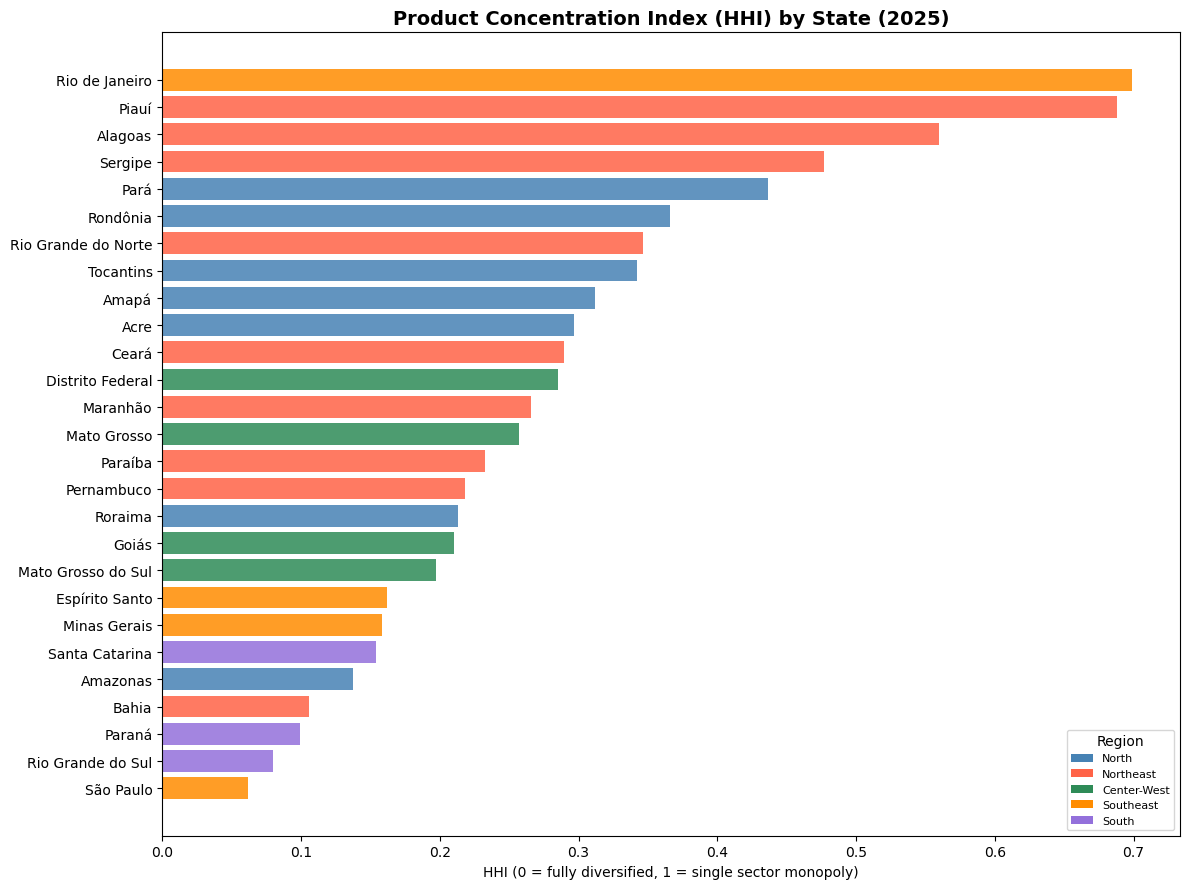


Product concentration HHI by state (2025)
Higher HHI = more concentrated in fewer sectors
              state      region  exports_usd_bn    hhi
     Rio de Janeiro   Southeast           48.98 0.6985
              Piauí   Northeast            1.20 0.6879
            Alagoas   Northeast            0.82 0.5594
            Sergipe   Northeast            0.45 0.4771
               Pará       North           24.34 0.4365
           Rondônia       North            3.09 0.3658
Rio Grande do Norte   Northeast            1.13 0.3462
          Tocantins       North            3.05 0.3418
              Amapá       North            0.14 0.3119
               Acre       North            0.10 0.2969
              Ceará   Northeast            2.28 0.2894
   Distrito Federal Center-West            0.32 0.2852
           Maranhão   Northeast            5.02 0.2660
        Mato Grosso Center-West           30.19 0.2571
            Paraíba   Northeast            0.18 0.2323
         Pernambuco   Northea

In [9]:
df_hhi_prod = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] ** 2).sum())
    .reset_index()
    .rename(columns={0: 'hhi'})
)
df_hhi_prod['hhi'] = df_hhi_prod['hhi'].round(4)
df_hhi_prod = df_hhi_prod.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_hhi_prod['region'] = df_hhi_prod['region'].map(region_name_map).fillna(df_hhi_prod['region'])

df_hhi_plot = df_hhi_prod.sort_values('hhi', ascending=True)

## Colour by region — rebuild colors from df_hhi_plot to match translated names
region_colors_hhi = {
    r: c for r, c in zip(
        df_hhi_prod['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_hhi_plot['region'].map(region_colors_hhi).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Product Concentration Index (HHI) by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('HHI (0 = fully diversified, 1 = single sector monopoly)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors_hhi.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b3_hhi_product.png', dpi=150)
plt.show()
print(f"\nProduct concentration HHI by state ({MAX_YEAR})")
print("Higher HHI = more concentrated in fewer sectors")
print(df_hhi_prod[['state', 'region', 'exports_usd_bn', 'hhi']]
      .sort_values('hhi', ascending=False)
      .to_string(index=False))

### Overview

**Range in this dataset: 0.062 (São Paulo) to 0.699 (Rio de Janeiro)**

---

### Featured States

**Rio de Janeiro (HHI 0.699)** — the most concentrated large exporter in Brazil by a significant margin. Oil and gas exports (\\$40.79bn) account for the overwhelming majority of the state's \\$48.98bn total — confirmed by the NCM analysis in cell 2.7. The combination of extreme concentration and large absolute export value is unique in the dataset — no other state of comparable size is this structurally dependent on a single sector.

**Ceará (HHI 0.289)** — resolves the open flag from the KSI analysis. Ceará has high KSI (1.59) but moderate HHI, which initially appears contradictory. The explanation is that Ceará's deviation from the national mix is driven by a cluster of related semi-manufactured steel products (NCM analysis in cell 2.7) — rather than a single dominant SH2 chapter. High specialisation relative to the national mix does not require internal concentration.

**Alagoas (HHI 0.559)** — the clearest multi-metric convergence in Step 2b. KSI 1.61 (highest in Brazil), HHI 0.559 and RCA above 16 all point to the same conclusion: Alagoas is Brazil's most monoculture-dependent exporting state across every metric simultaneously.

**Amazonas (HHI 0.137)** — lower concentration than expected given the Zona Franca de Manaus profile. Its low HHI reflects manufactured goods diversification across electronics, motorcycles and food processing — structurally different from the commodity diversification seen in Mato Grosso, which achieves a similar HHI (0.257) through multiple crop categories rather than industrial variety.

---

### Observations

**The KSI-HHI relationship is not straightforward.** A state can have high KSI (specialised relative to national) and moderate HHI (internally diversified), as Ceará demonstrates. Conversely a state can have moderate KSI and very high HHI, as Rio de Janeiro shows. These two metrics capture different dimensions of specialisation and should always be read together.

**Large export value does not guarantee diversification** — Rio de Janeiro (\\$48.98bn, HHI 0.699) and Pará (\\$24.34bn, HHI 0.437) are both large exporters with high concentration. Export scale and export diversification are structurally independent.

**The Sul states form a distinctly low-HHI cluster** — Paraná (0.099), Rio Grande do Sul (0.080) and Santa Catarina (0.154) all sit in the bottom third of the HHI ranking. This is the most consistently diversified region across all three metrics — RCA, KSI and HHI.

**Norte and Nordeste dominate the high-HHI end** — 9 of the top 10 most concentrated states are from these two regions. The exception being Rio de Janeiro (Southeast, oil-driven).

| HHI Band | States | Regional Pattern |
|---|---|---|
| > 0.40 | Rio de Janeiro, Piauí, Alagoas, Sergipe, Pará | Southeast outlier + North/Northeast commodity states |
| 0.20–0.40 | Rondônia, Rio Grande do Norte, Tocantins, Amapá, Acre, Ceará, DF, Maranhão, Mato Grosso, Paraíba, Pernambuco, Roraima, Goiás, Mato Grosso do Sul | Broad mix |
| < 0.20 | Espírito Santo, Minas Gerais, Santa Catarina, Amazonas, Bahia, Paraná, Rio Grande do Sul, São Paulo | Predominantly South and Southeast |


> ⚠️ *Rio de Janeiro's HHI (0.699) combined with \$48.98bn in exports represents the single largest concentration risk in Brazil's state-level export profile. A sustained decline in oil prices or an accelerated energy transition would disproportionately impact one of Brazil's largest exporting states.*

---
---

## 2b.4 — Export Frequency: Number of Shipments by State
Counting the number of export transactions (rows) per state per year as a proxy for shipment frequency.

In [10]:
query_freq = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           SUM(e."QT_ESTAT") AS total_units
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY shipment_count DESC
"""

df_freq = pd.read_sql(query_freq, engine)
df_freq = df_freq[~df_freq['state'].isin(['Não Declarada', 'Exterior'])]
df_freq['exports_usd_bn']    = (df_freq['exports_usd'] / 1e9).round(2)
df_freq['shipment_count_(000`s)']  = (df_freq['shipment_count'] / 1000).round(1)



print(f"\nExport shipment frequency by state ({MAX_YEAR})")
print(df_freq[['state', 'exports_usd_bn', 'shipment_count', 'shipment_count_(000`s)']]
      .sort_values('shipment_count', ascending=False)
      .to_string(index=False))


Export shipment frequency by state (2025)
              state  exports_usd_bn  shipment_count  shipment_count_(000`s)
          São Paulo           71.39          633996                   634.0
  Rio Grande do Sul           21.53          200290                   200.3
     Santa Catarina           12.20          198582                   198.6
             Paraná           23.65          168230                   168.2
     Rio de Janeiro           48.98          125063                   125.1
       Minas Gerais           45.83           84438                    84.4
     Espírito Santo           10.51           64958                    65.0
               Pará           24.34           30292                    30.3
           Maranhão            5.02           30183                    30.2
              Bahia           11.63           27716                    27.7
              Ceará            2.28           25439                    25.4
            Alagoas            0.82          

### Overview

Shipment frequency (number of export transactions) is used as a proxy for the operational profile of each state's export base. 

States with high shipment frequency tend toward lower product concentration (HHI) — a relationship quantified in the regression analysis in cell 2b.5 (pooled R² = 0.336, slope = -0.1226, significant in 25 of 29 years). Whether high frequency also corresponds to broader destination markets and smaller individual transaction sizes is examined in cells 2.17 (market concentration) while the relationship between frequency and individual transaction size is explored directly in cell 2b.5.

**Range in this dataset: 695 transactions (Sergipe) to 633,996 (São Paulo)**

The spread across this metric is the largest of any indicator in Step 2b — São Paulo transacts nearly 1,000 times more than Sergipe. This reflects a fundamental structural difference in how different Brazilian states participate in global trade.


***Note**: Shipment count is derived from row count in the `exp` table rather than an official transaction register — liquid bulk commodities such as oil may generate records at a different granularity than containerised or solid bulk goods, which could explain Rio de Janeiro's anomalously high frequency.*

---

### Key Findings

**São Paulo (634k transactions)** leads by a wide margin — nearly twice the frequency of Rio Grande do Sul (200k) in second place. This is consistent with São Paulo's role as Brazil's industrial and logistics hub, where diverse export products ship regularly across many sectors and destinations.

**Rio Grande do Sul (200k) and Santa Catarina (199k)** are virtually tied for second and third — both Sul states with diversified agro-industrial export bases generating high transaction volumes across meat, machinery, chemicals and agricultural products. Their frequency is disproportionately high relative to their export value, suggesting many smaller-value shipments rather than a few large ones.

**Rio de Janeiro (125k)** is the most analytically significant finding in this cell. With HHI 0.699 — the most concentrated export state in Brazil — one would expect low frequency. Instead it ranks fifth with 125k transactions, driven by the operational nature of oil and gas exports which generate many individual transaction records through the port processing system despite being a single commodity. This is the primary driver of the regression outlier identified in cell 2b.5.

**Mato Grosso (9.4k) and Mato Grosso do Sul (9.9k)** are the most striking low-frequency large exporters. Mato Grosso exports \\$30.19bn through only 9,400 transactions — fewer than Roraima (\\$0.24bn, 6.4k) on a per-value basis. This reflects the bulk agricultural nature of soybean and corn exports: very large individual shipments, very few transactions.

**Piauí (0.7k) and Sergipe (0.7k)** are the lowest frequency states — both small exporters with highly concentrated product profiles, consistent with their high HHI values.

---

### Observations

**Frequency scales with industrial diversification, not export value.** The top 5 states by frequency — São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Rio de Janeiro - are not the top 5 by export value — Mato Grosso (\\$30.19bn, ranked 3rd by value) ranks 17th by frequency. Frequency reflects how many distinct products and shipments a state generates, not how much revenue those shipments produce.

**The Southern cluster dominates mid-to-high frequency** — Paraná (168k), Rio Grande do Sul (200k) and Santa Catarina (199k) collectively generate 567k transactions on \\$57.4bn of exports. The Center-West generates \$54.7bn through only 35k transactions. Same export value, 16x fewer shipments — the clearest quantitative expression of the bulk commodity vs diversified industrial divide in Step 2b.

**The relationship between frequency and HHI is confirmed directionally** — states with low frequency (Mato Grosso, Piauí, Sergipe, Tocantins) all have high HHI, and states with high frequency (São Paulo, Rio Grande do Sul, Santa Catarina, Paraná) all have low HHI. Rio de Janeiro is the single exception, driven by oil port processing volumes rather than genuine product diversification. The regression in cell 2b.5 quantifies this relationship (pooled R² = 0.336, slope = -0.1226, significant in 25 of 29 years).

**The value-frequency ratio reveals the commodity-industrial divide.** Mato Grosso (\\$30.19bn, 9k transactions = \\$3.2m per transaction) vs São Paulo (\\$71.39bn, 634k transactions = \\$113k per transaction) illustrates the structural difference between bulk commodity and industrial export profiles more vividly than RCA or HHI alone.

**The Nordeste frequency range is the widest of any region** — from Bahia (28k) and Ceará (25k) at the top to Sergipe (695) and Piauí (704) at the bottom. This reflects the internal economic heterogeneity of the Nordeste — industrialising coastal states alongside underdeveloped agricultural interior states.

---

### Frequency Summary Table

| Tier | States | Shipment Count | Exports |
|---|---|---|---|
| High (> 100k) | São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Rio de Janeiro | 634k – 125k | \$12–71bn |
| Mid-High (25k–100k) | Minas Gerais, Espírito Santo, Pará, Maranhão, Bahia, Ceará | 84k – 25k | \$2–46bn |
| Mid-Low (5k–25k) | Alagoas, Pernambuco, Amazonas, Goiás, Mato Grosso do Sul, Mato Grosso, Roraima, Amapá | 19k – 5k | \$0.1–30bn |
| Low (< 5k) | Rondônia, Rio Grande do Norte, Distrito Federal, Tocantins, Paraíba, Acre, Piauí, Sergipe | 3.8k – 0.7k | \$0.1–3bn |

---
---

## 2b.5 — Export Frequency vs HHI: Does Product Concentration Predict How Often a State Trades?

Testing whether a state's product concentration (HHI) predicts its export transaction frequency — the hypothesis being that states concentrated in a few bulk commodities transact less frequently than diversified industrial states. 
The relationship is examined through a pooled panel regression covering 1997–2025 (n=783 state-year observations) with year-by-year results to test whether the relationship is stable over time. A single-year regression is presented for context but is insufficient on its own given the small cross-section of 27 states.

Non-geographic entries (CONSUMO DE BORDO, MERCADORIA NACIONALIZADA, REEXPORTACAO) are excluded from the regression at the SQL level — these categories generate transaction records that do not correspond to actual state-level export operations and introduce noise into both the frequency count and the HHI calculation. Excluding them improves model fit and reduces standard error.


***Note**: The baseline results presented here are extended in Step 2c, which covers robustness checks across five specifications, the COVID structural break and the post-2015 weakening trend in detail.*

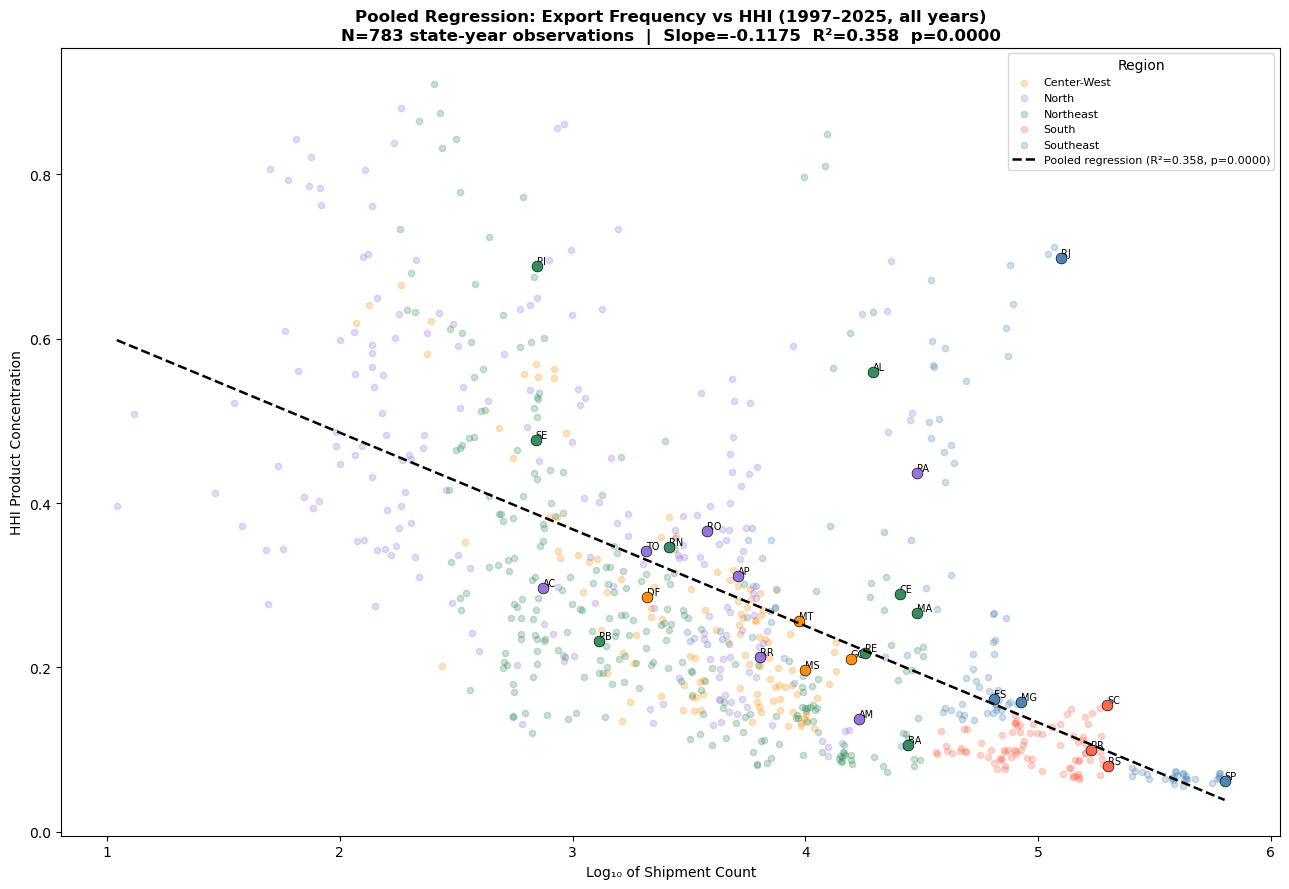


Pooled Regression Results (1997–2025, all years)
  N observations: 783
  Slope:          -0.1175
  Intercept:      0.7207
  R²:             0.3578
  p-value:        0.000000
  Std Error:      0.0056


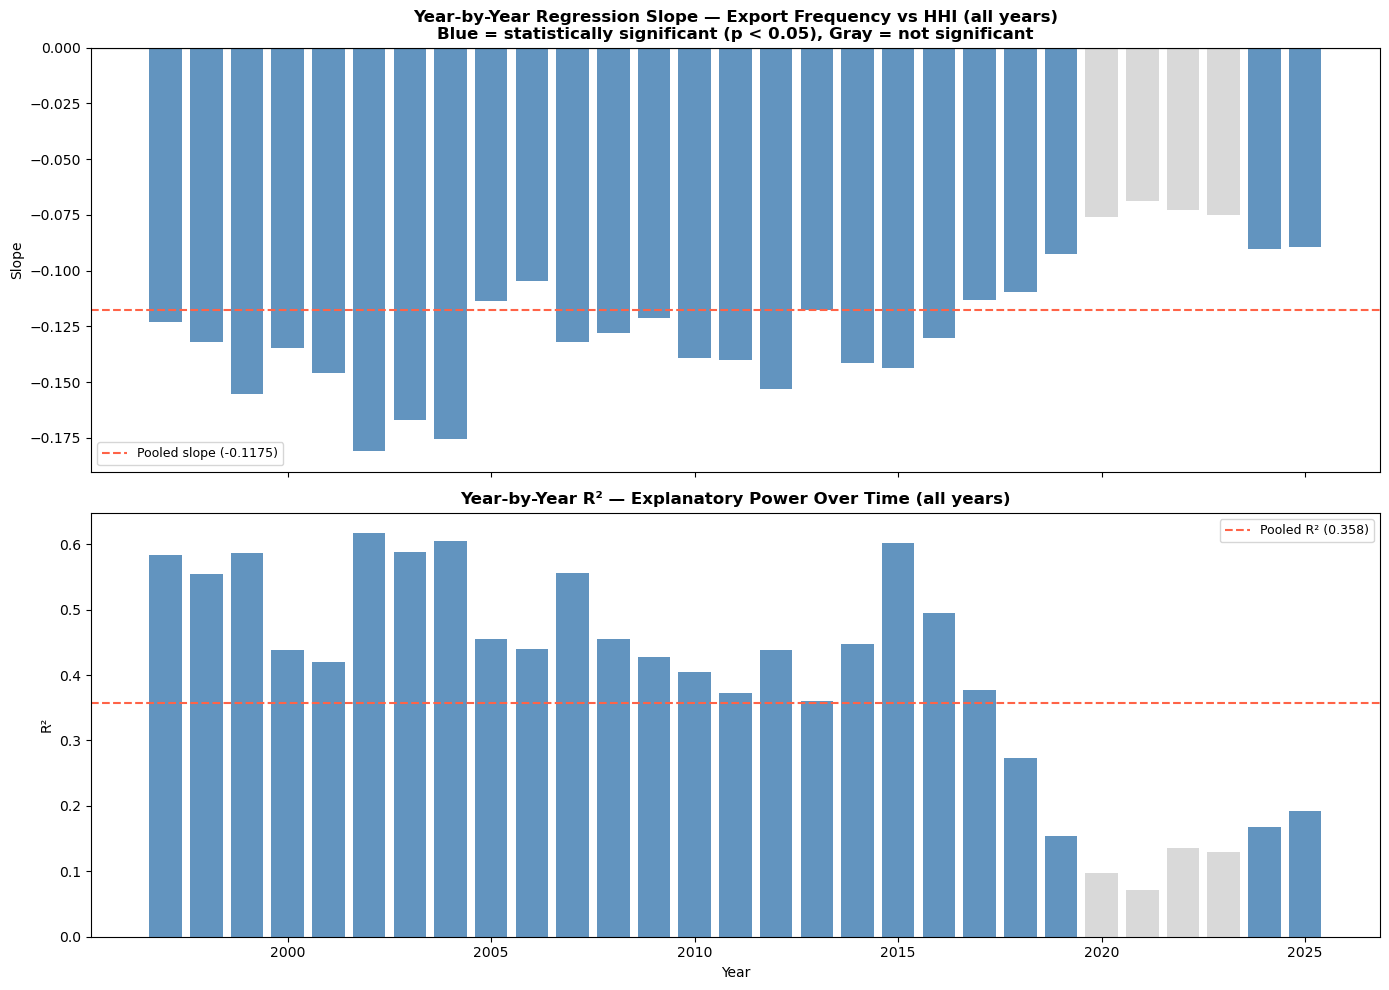


Year-by-Year Regression Results (all years):
 year   slope  r_squared  p_value  n
 1997 -0.1232     0.5834   0.0000 27
 1998 -0.1320     0.5548   0.0000 27
 1999 -0.1553     0.5864   0.0000 27
 2000 -0.1348     0.4378   0.0002 27
 2001 -0.1458     0.4197   0.0003 27
 2002 -0.1811     0.6172   0.0000 27
 2003 -0.1672     0.5876   0.0000 27
 2004 -0.1757     0.6051   0.0000 27
 2005 -0.1137     0.4555   0.0001 27
 2006 -0.1045     0.4393   0.0002 27
 2007 -0.1320     0.5562   0.0000 27
 2008 -0.1281     0.4555   0.0001 27
 2009 -0.1211     0.4283   0.0002 27
 2010 -0.1392     0.4050   0.0004 27
 2011 -0.1403     0.3727   0.0007 27
 2012 -0.1531     0.4376   0.0002 27
 2013 -0.1176     0.3606   0.0009 27
 2014 -0.1416     0.4471   0.0001 27
 2015 -0.1437     0.6024   0.0000 27
 2016 -0.1300     0.4946   0.0000 27
 2017 -0.1130     0.3767   0.0007 27
 2018 -0.1096     0.2732   0.0052 27
 2019 -0.0924     0.1540   0.0429 27
 2020 -0.0758     0.0978   0.1122 27
 2021 -0.0686     0.0709   0.

In [11]:
## Regression: Export Shipment Frequency vs HHI — All Years (1997–MAX_YEAR)
## All years included — non-geographic entries filtered from uf table
## Pooled panel regression + year-by-year regression to test structural stability

## ---- Query: frequency and HHI for all years ----
query_freq_all_v2 = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, shipment_count DESC
"""

query_hhi_all_v2 = f"""
    SELECT year, uf,
           SUM(sector_exports * sector_exports) /
           (SUM(sector_exports) * SUM(sector_exports)) AS hhi
    FROM (
        SELECT e."CO_ANO" AS year,
               e."SG_UF_NCM" AS uf,
               s.codigo_sh2,
               SUM(e."VL_FOB") AS sector_exports
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
        WHERE e."CO_ANO" <= {MAX_YEAR}
        AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        GROUP BY e."CO_ANO", e."SG_UF_NCM", s.codigo_sh2
    ) t
    GROUP BY year, uf
    ORDER BY year, uf
"""

df_freq_all_v2 = pd.read_sql(query_freq_all_v2, engine)
df_hhi_all_v2  = pd.read_sql(query_hhi_all_v2,  engine)

df_freq_all_v2['exports_usd_bn'] = df_freq_all_v2['exports_usd'] / 1e9

## Merge and clean
df_panel_v2 = df_freq_all_v2.merge(df_hhi_all_v2, on=['year', 'uf'], how='inner')
df_panel_v2 = df_panel_v2.merge(df_state[['uf', 'region']], on='uf', how='left')
df_panel_v2 = df_panel_v2[~df_panel_v2['state'].isin(['Não Declarada', 'Exterior'])]

## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
}
df_panel_v2['region'] = df_panel_v2['region'].map(region_name_map).fillna(df_panel_v2['region'])

df_panel_v2['log_shipment_count'] = np.log10(df_panel_v2['shipment_count'])

## ---- Part 1: Pooled regression (all years) ----
slope_p2, intercept_p2, r_value_p2, p_value_p2, std_err_p2 = stats.linregress(
    df_panel_v2['log_shipment_count'], df_panel_v2['hhi']
)
r_squared_p2 = r_value_p2 ** 2

x_line2 = np.linspace(df_panel_v2['log_shipment_count'].min(),
                      df_panel_v2['log_shipment_count'].max(), 100)
y_line2 = slope_p2 * x_line2 + intercept_p2

region_colors_reg2 = {
    r: c for r, c in zip(
        df_panel_v2['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

fig, ax = plt.subplots(figsize=(13, 9))
for region, group in df_panel_v2.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(
        group['log_shipment_count'],
        group['hhi'],
        label=region,
        color=color,
        s=20,
        alpha=0.25,
        zorder=2
    )

## Overlay MAX_YEAR points with labels
df_latest_v2 = df_panel_v2[df_panel_v2['year'] == MAX_YEAR]
for region, group in df_latest_v2.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(group['log_shipment_count'], group['hhi'],
               color=color, s=60, alpha=0.95, zorder=4,
               edgecolors='black', linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['log_shipment_count'], row['hhi']),
                    fontsize=7, ha='left', va='bottom')

ax.plot(x_line2, y_line2, color='black', linewidth=1.8, linestyle='--',
        label=f'Pooled regression (R²={r_squared_p2:.3f}, p={p_value_p2:.4f})',
        zorder=5)

ax.set_title(
    f'Pooled Regression: Export Frequency vs HHI (1997–{MAX_YEAR}, all years)\n'
    f'N={len(df_panel_v2)} state-year observations  |  '
    f'Slope={slope_p2:.4f}  R²={r_squared_p2:.3f}  p={p_value_p2:.4f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Log₁₀ of Shipment Count')
ax.set_ylabel('HHI Product Concentration')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b5_regression_pooled_all_years.png', dpi=150)
plt.show()

print(f"\nPooled Regression Results (1997–{MAX_YEAR}, all years)")
print(f"  N observations: {len(df_panel_v2)}")
print(f"  Slope:          {slope_p2:.4f}")
print(f"  Intercept:      {intercept_p2:.4f}")
print(f"  R²:             {r_squared_p2:.4f}")
print(f"  p-value:        {p_value_p2:.6f}")
print(f"  Std Error:      {std_err_p2:.4f}")

## ---- Part 2: Year-by-year regression ----
yearly_results_v2 = []
for year, group in df_panel_v2.groupby('year'):
    if len(group) < 5:
        continue
    s, i, r, p, se = stats.linregress(group['log_shipment_count'], group['hhi'])
    yearly_results_v2.append({
        'year'     : year,
        'slope'    : round(s, 4),
        'r_squared': round(r ** 2, 4),
        'p_value'  : round(p, 4),
        'n'        : len(group)
    })

df_yearly_v2 = pd.DataFrame(yearly_results_v2)

## Plot year-by-year slope and R²
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors_sig2 = ['steelblue' if p < 0.05 else 'lightgray' for p in df_yearly_v2['p_value']]

ax1.bar(df_yearly_v2['year'], df_yearly_v2['slope'], color=colors_sig2, alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axhline(y=slope_p2, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_p2:.4f})')
ax1.set_title(
    'Year-by-Year Regression Slope — Export Frequency vs HHI (all years)\n'
    'Blue = statistically significant (p < 0.05), Gray = not significant',
    fontsize=12, fontweight='bold'
)
ax1.set_ylabel('Slope')
ax1.legend(fontsize=9)

ax2.bar(df_yearly_v2['year'], df_yearly_v2['r_squared'], color=colors_sig2, alpha=0.85)
ax2.axhline(y=r_squared_p2, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r_squared_p2:.3f})')
ax2.set_title(
    'Year-by-Year R² — Explanatory Power Over Time (all years)',
    fontsize=12, fontweight='bold'
)
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output_2b5_regression_yearly_all_years.png', dpi=150)
plt.show()

print(f"\nYear-by-Year Regression Results (all years):")
print(df_yearly_v2.to_string(index=False))

## Summary statistics
sig_years_v2 = df_yearly_v2[df_yearly_v2['p_value'] < 0.05]
print(f"\n  Significant years (p < 0.05): {len(sig_years_v2)} of {len(df_yearly_v2)}")
print(f"  Average slope (all years):        {df_yearly_v2['slope'].mean():.4f}")
print(f"  Average slope (significant only): {sig_years_v2['slope'].mean():.4f}")
print(f"  Average R² (all years):           {df_yearly_v2['r_squared'].mean():.4f}")
print(f"  Average R² (significant only):    {sig_years_v2['r_squared'].mean():.4f}")

### Overview

Testing whether states that export more frequently also tend to have more diversified product baskets. A statistically significant negative relationship confirms that high-frequency states such as São Paulo, Rio Grande do Sul and Santa Catarina are also the most diversified exporters. Rio de Janeiro is the key outlier — high frequency but the most concentrated export basket in Brazil, driven by ports oil and gas processing volumes rather than genuine product diversification. States are plotted on a log scale given the large range in shipment counts across Brazil's 27 states. Bubble size reflects total export value.

COVID-19 (2020–2023) represents a structural break in the frequency-HHI relationship. During this period the regression loses explanatory power with all four identified non-significant years appearing year-by-year after COVID. The v3 specification (excluding both non-geographic entries and COVID years) confirms this: R² rises to 0.440 and all 25 remaining years are statistically significant, compared to 25 of 29 in the baseline. The COVID years are retained in the primary specification to preserve the full time series, but their influence on the pooled estimate should be interpreted with caution.

*A full analysis across five specifications — including COVID exclusion, Rio de Janeiro exclusion and their combination — is presented in Step 2c.*

### Pooled Regression Summary

| Metric | Value |
|---|---|
| N observations | 783 (27 states × ~29 years, non-geographic regions excluded) |
| Slope | -0.1175 |
| Intercept | 0.7207 |
| R² | 0.3578 |
| p-value | < 0.000001 |
| Std Error | 0.0056 |


The pooled regression summary reports the results of running a single regression across all 783 state-year observations simultaneously — treating each state in each year as one data point — rather than running 29 separate single-year regressions. This approach substantially increases statistical power: instead of 27 observations per year, the pooled model uses the full panel of 783 observations, making the slope estimate more stable and the p-value more reliable.

The slope of -0.1175 means that a 10-fold increase in shipment frequency (one unit on the log scale) is associated with an HHI decrease of approximately 0.12, in other words states that transact 10 times more frequently tend to have product concentration scores roughly 0.12 lower, meaning they are more diversified. Given that the HHI range in this dataset runs from 0.062 (São Paulo) to 0.699 (Rio de Janeiro), a difference of 0.12 is economically meaningful.

The R² of 0.358 means that log shipment frequency alone explains approximately 36% of the variation in product concentration across all states and years. The remaining 64% reflects other structural factors — likely candidates include geography, infrastructure, commodity price cycles and state industrial policy — but these cannot be confirmed from trade flow data alone.
The p-value of < 0.000001 confirms the relationship is not due to chance.

---

### Year-by-Year Findings

**Significance**

**25 of 29 years are statistically significant at p < 0.05.** The four non-significant years are 2020, 2021, 2022 and 2023 — a concentrated cluster during and immediately after COVID-19.

**The COVID-19 Disruption (2020–2023)**

The four non-significant years form a clear structural break in the relationship:

| Year | Slope | R² | p-value | Statistically Significant |
|---|---|---|---|---|
| 2019 | -0.0924 | 0.154 | 0.043 | Yes (barely) |
| 2020 | -0.0758 | 0.098 | 0.112 | **No** |
| 2021 | -0.0686 | 0.071 | 0.180 | **No** |
| 2022 | -0.0727 | 0.136 | 0.059 | **No** |
| 2023 | -0.0749 | 0.130 | 0.065 | **No** |
| 2024 | -0.0902 | 0.168 | 0.034 | Yes |
| 2025 | -0.0896 | 0.192 | 0.022 | Yes |


During 2020–2023 the relationship between frequency and concentration weakened. The data does not identify the mechanism — possible explanations include supply chain disruptions disproportionately affecting high-frequency industrial exporters, or commodity price surges altering the HHI denominator without a corresponding change in product mix, but these cannot be confirmed from trade flow data alone.

The recovery in 2024 and 2025 (p = 0.034 and 0.022 respectively) suggests the relationship is re-establishing itself, though R² remains below pre-COVID levels.

> ⚠️ *The COVID-19 period (2020–2023) represents a structural break in the frequency-concentration relationship. Any single-year regression drawn from this window would produce unreliable results. This is a key methodological reason why the pooled regression is more reliable than any individual year.*


---

### The Long-Run Trend: Weakening Relationship Post-2015

The year-by-year results reveal a structural shift that predates COVID:

**1997–2015**
- Average slope: approximately -0.138
- Average R²: approximately 0.47
- All years significant, most with p < 0.001

**2016–2025**
- Average slope: approximately -0.089
- Average R²: approximately 0.16
- Several years non-significant or borderline

This weakening predates COVID and persists through 2025 in both regressions. The trade flow data cannot identify the mechanism — it records what states exported and in what quantities, but not why the frequency-concentration relationship changed structurally from around 2015. Confirming the cause would require further analysis utilizing production data, port infrastructure investment data and agricultural land use data that are outside the scope of this dataset.

> ⚠️ *The post-2015 weakening is a notable finding in this analysis. It predates COVID, appears in both regressions simultaneously, and has not recovered to pre-2015 levels. It represents the primary unresolved structural question entering Steps 3–9.*

---

### Comparison: Single Year vs Pooled vs Year-by-Year

| Approach | N | Slope | R² | p-value | Reliability |
|---|---|---|---|---|---|
| Single year (2025) | 27 | -0.0896 | 0.192 | 0.022 | Low — small n, post-COVID recovery year |
| Pooled (1997–2025) | 783 | -0.1175 | 0.358 | ~0 | High — full structural picture |
| Year avg (all) | 29 years | -0.1255 | 0.360 | — | Medium — shows trend but no pooling |
| Year avg (sig only) | 25 years | -0.1339 | 0.400 | — | Medium — excludes COVID disruption |
| Year avg (1997–2015) | 19 years | ~-0.138 | ~0.47 | — | Reference — pre-structural break period |
| Year avg (2016–2025) | 10 years | ~-0.089 | ~0.16 | — | Reference — post-structural break period |

The four approaches tell a consistent story with different levels of precision.

The single-year result (2025) uses only 27 observations — one per state. The slope of -0.0896 and R² of 0.192 are statistically significant (p = 0.022) but unreliable as an estimate due to the limited number of observations: 2025 appears to be a recovery year where the relationship has not yet returned to pre-pandemic levels, meaning the single-year result captures a transitional period rather than the long-run structural relationship.

The pooled result (n=783) multiplies the sample by nearly 30, incorporating variation across both states and years simultaneously. The slope steepens to -0.1175 and R² rises to 0.358 — both changes in the expected direction as the COVID-period noise is diluted by 25 years of pre-COVID signal. The p-value of effectively zero reflects the near-certainty that the relationship is real rather than a statistical artefact of any single year.

The year averages (rows 3 and 4) are presented for context. Averaging 29 individual slopes is not equivalent to pooling — it treats each year equally regardless of sample size and does not account for cross-year correlations. The fact that the year-average slopes (-0.1255 and -0.1339) are steeper than the pooled slope (-0.1175) reflects the downward pull of COVID years in the pooled estimate. The significant-years-only average (-0.1339) is the closest approximation to the pre-COVID structural relationship.

The pre/post 2015 split (rows 5 and 6) quantifies the structural break identified in the year-by-year analysis. The 1997–2015 period shows a slope of approximately -0.138 and average R² of 0.47 — a stronger and more stable relationship than the full panel. 

The 2016–2025 period shows a slope of approximately -0.089 and average R² of 0.16 — materially weaker across both measures. The difference between these two periods (-0.049 in slope, -0.31 in R²) is an expression of the post-2015 structural weakening documented above.

Taken together, the structural slope is approximately **-0.12 to -0.13** — the pooled result provides the primary estimate and the significant-years average provides the upper bound of the pre-COVID relationship. The pre-2015 period suggests the relationship was structurally stronger before the post-2015 weakening and COVID disruption, with a slope closer to -0.14

---

### Conclusion

The pooled regression confirms that the negative relationship between export frequency and product concentration is a structural and persistent feature of Brazil's trade — not a statistical artefact of any single year. It has held across 25 of 29 years from 1997 to 2025.

Two findings beyond the headline result are worth noting:

1. **COVID-19 temporarily broke the relationship (2020–2023)** — shipment frequency lost its predictive power during the pandemic and appears to be recovering in 2024 and 2025. The four non-significant years fall entirely within the COVID window, which is consistent with the Step 1 finding that Brazil's goods trade showed resilience during this period — though the specific mechanism linking the two observations cannot be confirmed from this data alone.

2. **The relationship has been weakening since 2015** — the pre-2015 period shows a structurally stronger relationship (avg slope -0.138, avg R² 0.47) compared to 2016–2025 (avg slope -0.089, avg R² 0.16). The trade flow data cannot identify the cause of this shift.

The pre-2015 period suggests the relationship was structurally stronger before the post-2015 weakening and COVID disruption, with a slope closer to -0.14. The pooled estimate (R² = 0.358, slope = -0.1175) should be treated as the primary result — it captures the full period including both the stronger pre-2015 signal, the weaker post-2015 signal as well as three economic disruptions: the 2009 global financial crisis, the 2014–2016 Brazilian recession and the COVID-19 pandemic.

---
---

## 2b.6 — Export Value Density by State: How Much Value Does Each kg Generate?
Export value density (USD/kg) measures how much export revenue each state generates per kilogram shipped. It is calculated as total export value divided by total net weight across all transactions in MAX_YEAR.

A high USD/kg ratio suggests exports are weighted toward processed, manufactured or high-value goods. A low USD/kg ratio suggests exports are weighted toward heavy bulk commodities where physical weight far exceeds unit value. This interpretation is directional rather than definitive — the USD/kg ratio is a single aggregate measure and should be read alongside the product classification in cell 2.13 and the HHI in cell 2b.3 to confirm the underlying product mix driving each state's position.

Shipment size data loaded: 27 states
              state  exports_usd_bn  avg_kg_per_shipment  avg_usd_per_kg  shipment_count
          São Paulo       71.291739         1.044236e+05        1.197959          569900
     Rio de Janeiro       48.929939         1.039054e+06        0.420935          111872
       Minas Gerais       45.815662         2.748648e+06        0.221181           75361
        Mato Grosso       30.189423         7.295509e+06        0.441254            9378
               Pará       24.335929         6.359724e+06        0.128284           29829
             Paraná       23.649353         2.168225e+05        0.691917          157638
  Rio Grande do Sul       21.529254         1.379137e+05        0.829499          188194
              Goiás       13.469340         1.562807e+06        0.565160           15250
     Santa Catarina       12.194590         5.209831e+04        1.256266          186321
              Bahia       11.628139         6.327819e+05        0.681434 

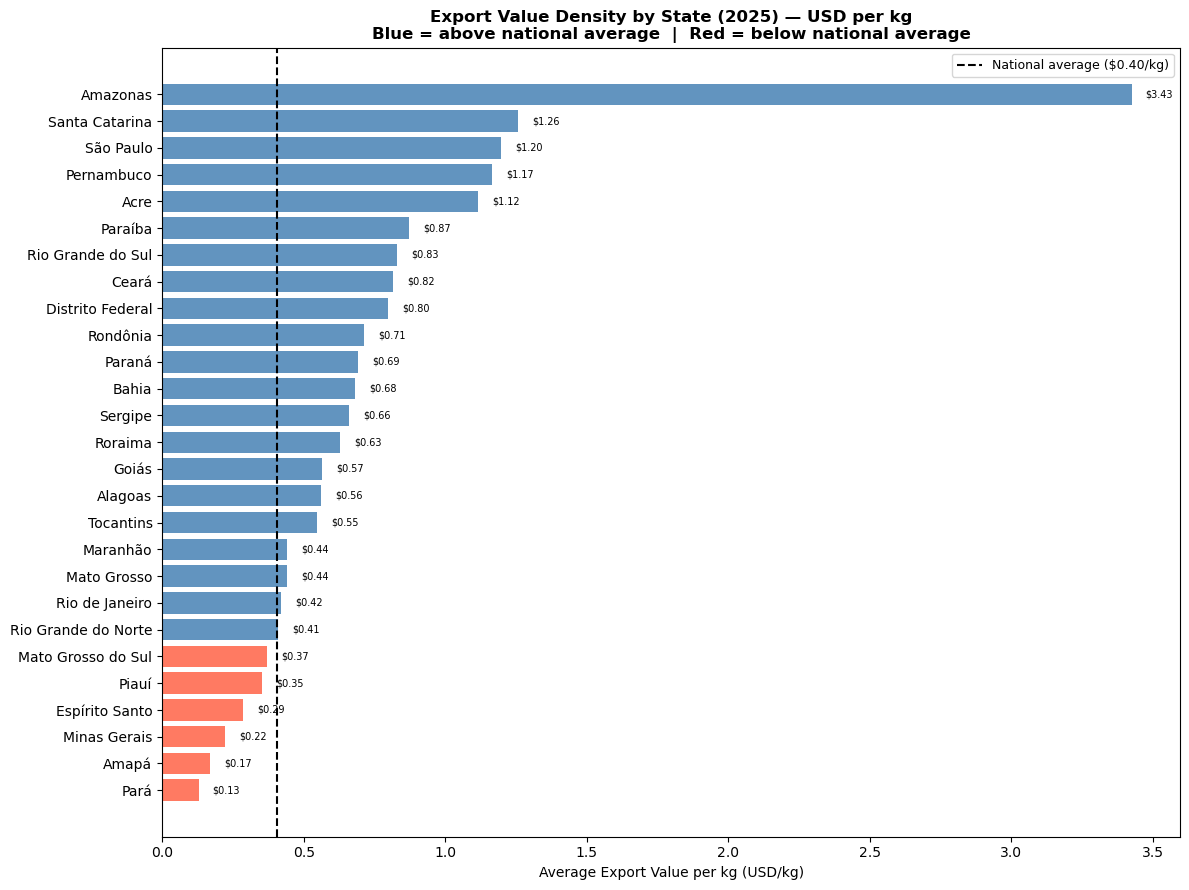


Export value density by state (2025)
National average: $0.40/kg
              state  avg_usd_per_kg
           Amazonas        3.425879
     Santa Catarina        1.256266
          São Paulo        1.197959
         Pernambuco        1.166532
               Acre        1.116590
            Paraíba        0.872938
  Rio Grande do Sul        0.829499
              Ceará        0.816669
   Distrito Federal        0.796678
           Rondônia        0.714376
             Paraná        0.691917
              Bahia        0.681434
            Sergipe        0.661040
            Roraima        0.629904
              Goiás        0.565160
            Alagoas        0.562546
          Tocantins        0.547690
           Maranhão        0.441277
        Mato Grosso        0.441254
     Rio de Janeiro        0.420935
Rio Grande do Norte        0.408132
 Mato Grosso do Sul        0.370936
              Piauí        0.352108
     Espírito Santo        0.287232
       Minas Gerais        0.221181

In [24]:
## Export value density — USD per kg by state
## High ratio = high value-added exports (industrial/processed goods)
## Low ratio  = low value per kg (bulk commodity exports)

## Average shipment size by state (MAX_YEAR)
query_shipsize = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           COUNT(*) AS shipment_count
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."KG_LIQUIDO" > 0
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY exports_usd DESC
"""

df_shipsize = pd.read_sql(query_shipsize, engine)
df_shipsize = df_shipsize[~df_shipsize['state'].isin(['Não Declarada', 'Exterior'])]
df_shipsize['avg_kg_per_shipment']  = df_shipsize['total_kg']    / df_shipsize['shipment_count']
df_shipsize['avg_usd_per_shipment'] = df_shipsize['exports_usd'] / df_shipsize['shipment_count']
df_shipsize['avg_usd_per_kg']       = df_shipsize['exports_usd'] / df_shipsize['total_kg']
df_shipsize['exports_usd_bn']       = df_shipsize['exports_usd'] / 1e9

print(f"Shipment size data loaded: {len(df_shipsize)} states")
print(df_shipsize[['state', 'exports_usd_bn', 'avg_kg_per_shipment',
                    'avg_usd_per_kg', 'shipment_count']].to_string(index=False))

## Value density chart
national_avg_usd_per_kg = df_shipsize['exports_usd'].sum() / df_shipsize['total_kg'].sum()
df_ratio_plot = df_shipsize.sort_values('avg_usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_avg_usd_per_kg else 'tomato'
          for x in df_ratio_plot['avg_usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_ratio_plot['state'], df_ratio_plot['avg_usd_per_kg'],
        color=colors, alpha=0.85)
ax.axvline(x=national_avg_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_avg_usd_per_kg:.2f}/kg)')
for i, (_, row) in enumerate(df_ratio_plot.iterrows()):
    ax.text(row['avg_usd_per_kg'] + 0.05, i,
            f'${row["avg_usd_per_kg"]:.2f}',
            va='center', fontsize=7)
ax.set_title(
    f'Export Value Density by State ({MAX_YEAR}) — USD per kg\n'
    f'Blue = above national average  |  Red = below national average',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Average Export Value per kg (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2b6_usd_per_kg_ratio.png', dpi=150)
plt.show()

print(f'\nExport value density by state ({MAX_YEAR})')
print(f'National average: ${national_avg_usd_per_kg:.2f}/kg')
print(df_shipsize[['state', 'avg_usd_per_kg']]
      .sort_values('avg_usd_per_kg', ascending=False)
      .to_string(index=False))

## Regional Pattern

| Region | Avg USD/kg | Exports (USD, bn) | Total Weight (Kg, bn) | Shipments |
|---|---|---|---|---|
| North | \~\\$0.16/kg | 31.90 | 201.20 | 63,103 |
| Southeast | \~\\$0.42/kg | 176.54 | 419.48 | 820,025 |
| Center-West | \~\\$0.45/kg | 54.73 | 121.64 | 36,396 |
| Northeast | \~\\$0.60/kg | 25.25 | 41.93 | 123,036 |
| South | \~\\$0.82/kg | 57.37 | 69.84 | 532,153 |

**North (\~\\$0.16/kg, \~3.2M kg/shipment)** — the lowest value density and largest average shipment size in the dataset. As shown in 2.13, the North is \~80% primary commodity by composition share, with a modest absolute export base. Shipment count (63,103) is low relative to export volume suggeting large volume of shipments.

**Southeast (\~\\$0.42/kg, \~511K kg/shipment)** — the most heterogeneous region; its average is the least informative. As shown in 2.13, the manufactured component alone represents more absolute value than most other regions' entire export base. São Paulo (104K kg/shipment, \\$1.20/kg) and Minas Gerais (2.7M kg/shipment, \\$0.22/kg) represent near-opposite profiles within the same average. Shipment count (820,025) exceeds the remaining four regions combined. Exact product distribution will be evaluated in Step 5.

**Center-West (\~\\$0.45/kg, \~3.3M kg/shipment)** — near-identical primary commodity composition share to the North (2.13), but a larger absolute export base accounts for the value density gap between the two regions despite similar shipment sizes. Shipment count (36,396) is the lowest of any region, but higher value average USD/Kg suggests higher value imports.

**Northeast (\~\\$0.60/kg, \~341K kg/shipment)** — above-average value density driven by Pernambuco and Ceará, which carry the highest manufactured share in the region (2.13). The Northeast has the smallest absolute export base of any region, which limits the weight of the regional average calculated above.

**South (\~\\$0.82/kg, \~131K kg/shipment)** — the most consistent region. As shown in 2.13, the South's manufactured component in absolute value is comparable to the North's entire export base, achieved across a high shipment count (532,153) and smaller consignment sizes.

--------------------------------------------------------------------------------------------------------------------------------------------------------

### Key Findings

**National average: \$0.40/kg** — the distribution is heavily right-skewed due to Amazonas, which sits 8.6x above the national average. Removing Amazonas the next tier (Santa Catarina, São Paulo, Pernambuco) clusters between \\$1.17 and \\$1.26/kg — approximately 3x the national average.

**Amazonas (\$3.43/kg)** — the most extreme value in the dataset and confirmed as an outlier in Regression 2. The Zona Franca de Manaus likely drives this through manufactured goods exports with high value relative to their physical weight. No other state approaches this level, with the next tier being 65% lower.

**Pará (\$0.13/kg)** — the lowest value density in Brazil, consistent with iron ore and copper concentrate exports where physical weight dominates relative to unit value. Pará ships more weight than almost any other state (4th overall) but generates the least revenue per kg.

**Rio de Janeiro (\$0.42/kg)** — just above the national average despite being the second largest exporter. This is driven by crude petroleum, which accounts for \\$38.82bn of the state’s \\$48.93bn in exports (see 2.13), and will be explored further in Step 5.

**Pernambuco (\\$1.17/kg) stands out.** It sits alongside São Paulo and Santa Catarina in value density — a Nordeste state generating industrial-level value per kg. This driver is not immediately apparent from aggregate data and warrants future attention in Step 5.

---

### Observations

**The Southern cluster** — Paraná (\\$0.69/kg), Rio Grande do Sul (\\$0.83/kg) and Santa Catarina (\\$1.26/kg) all sit well above the national average, consistent with their High-Value Industrial classification in cell 2b.7. With Santa Catarina standing out as a high-value outlier within the region.

**Acre (\\$1.12/kg) and Paraíba (\\$0.87/kg)** — both above \\$0.80/kg but with negligible export volumes (\\$0.10bn and \\$0.18bn respectively). As flagged in the RCA analysis, high USD/kg on a small base reflects reflects narrow export specialisation rather than broad-based export capacity.

**Minas Gerais (\\$0.22/kg)** — the most counterintuitive result among large exporters. Heavy raw materials skew the weight profile sufficiently to produce the second lowest value density among the top 10 exporters. As shown in 2.13, Minas Gerais remains heavily concentrated in unprocessed minerals and agricultural commodities.

The composition data in 2.13 confirms this is driven by product type: primary commodity-dominant states move large, low-value consignments; manufactured-dominant states move smaller, higher-value ones. Amazonas is the exception — the highest manufactured share of any state (2.13) at 18K kg/shipment and $3.43/kg. Overall, the results confirm that export value density in Brazil is driven primarily by product composition rather than export scale, with industrialized states achieving significantly higher USD/kg than commodity-based exporters

---
---

## 2b.7 — Logistics Profile Summary: Bulk vs High-Frequency Exporters

Combining average shipment size (kg per transaction) and export value density (USD/kg) to classify each state into one of four logistics profiles. States are plotted on a scatter chart where position reflects the physical and economic characteristics of their export base rather than total export value.

The median is used rather than the mean given the skewed distribution of both variables across states — extreme values such as Amazonas (USD/kg) and Mato Grosso (kg per shipment) would pull mean thresholds away from the typical state's position.

The four-quadrant classification is constructed using the national median thresholds for both dimensions as split points. This approach follows the weight-to-value ratio framework used in trade logistics analysis — where USD/kg serves as a proxy for goods complexity and value-added content, and average shipment size serves as a proxy for logistics infrastructure requirements — applied here at the state level using Brazil's own median as the reference rather than an external benchmark. The four quadrants defined by the national median thresholds are:

| Quadrant | Avg shipment size | USD/kg | Profile |
|---|---|---|---|
| Bulk Commodity | High | Low | Heavy raw materials, infrequent large shipments |
| Large High-Value | High | High | High-value commodities or processed goods at scale |
| High-Value Industrial | Low | High | Manufactured or processed goods, frequent smaller shipments |
| Small Low-Value | Low | Low | Small-volume exporters without a clear value advantage |


**Result Distribution**: 10 Bulk Commodity, 10 High-Value Industrial, 3 Large High-Value, 4 Small Low-Value - the near-even split between the two dominant quadrants is expected given the median-based thresholds and does not in itself indicate structural balance between commodity and industrial exporters.

This classification draws together the RCA, KSI, HHI and frequency findings from cells 2b.1 through 2b.5 into a single spatial representation — each state's position on the chart is the physical expression of its broader competitiveness profile.

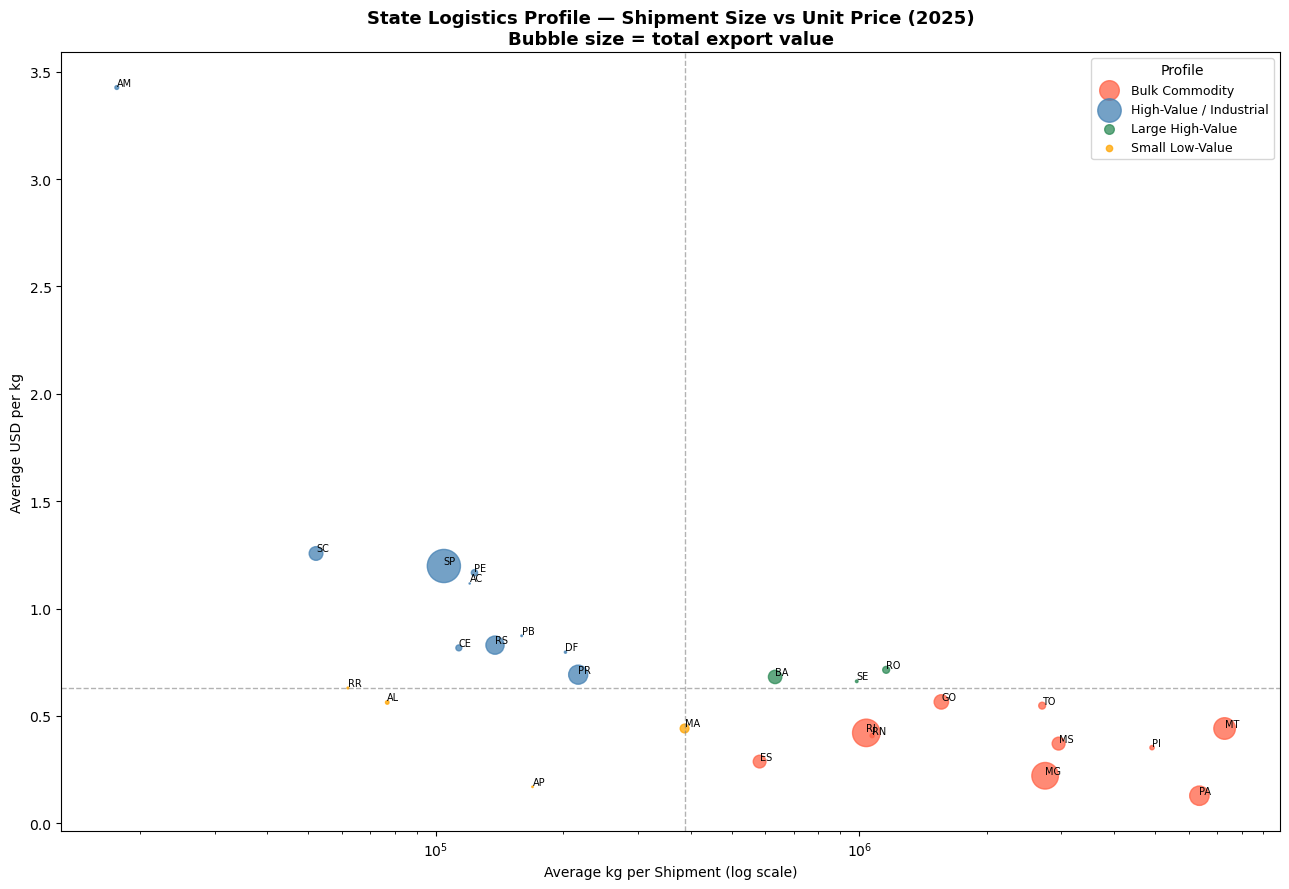


State logistics profile classification (2025)
Median avg kg/shipment: 386,730 | Median avg USD/kg: $0.63
              state              region                 profile  exports_usd_bn  avg_kg_per_shipment  avg_usd_per_kg    hhi
     Rio de Janeiro      REGIAO SUDESTE          Bulk Commodity       48.929939         1.039054e+06        0.420935 0.6985
       Minas Gerais      REGIAO SUDESTE          Bulk Commodity       45.815662         2.748648e+06        0.221181 0.1585
        Mato Grosso REGIAO CENTRO OESTE          Bulk Commodity       30.189423         7.295509e+06        0.441254 0.2571
               Pará        REGIAO NORTE          Bulk Commodity       24.335929         6.359724e+06        0.128284 0.4365
              Goiás REGIAO CENTRO OESTE          Bulk Commodity       13.469340         1.562807e+06        0.565160 0.2105
Rio Grande do Norte     REGIAO NORDESTE          Bulk Commodity        1.123873         1.072730e+06        0.408132 0.3462
 Mato Grosso do Sul REGIAO

In [14]:
## Combine frequency and size metrics
df_logistics = df_shipsize[[
    'uf', 'state', 'exports_usd_bn', 'shipment_count',
    'avg_kg_per_shipment', 'avg_usd_per_shipment', 'avg_usd_per_kg'
]].copy()
df_logistics = df_logistics.merge(df_state[['uf', 'region']], on='uf', how='left')
df_logistics = df_logistics.merge(df_hhi_prod[['uf', 'hhi']], on='uf', how='left')

## Classify profile based on median thresholds
med_kg  = df_logistics['avg_kg_per_shipment'].median()
med_usd = df_logistics['avg_usd_per_kg'].median()

def classify_profile(row):
    high_kg  = row['avg_kg_per_shipment'] > med_kg
    high_usd = row['avg_usd_per_kg'] > med_usd
    if high_kg and not high_usd:
        return 'Bulk Commodity'
    elif not high_kg and high_usd:
        return 'High-Value / Industrial'
    elif high_kg and high_usd:
        return 'Large High-Value'
    else:
        return 'Small Low-Value'

df_logistics['profile'] = df_logistics.apply(classify_profile, axis=1)

## Scatter plot: avg kg per shipment vs avg USD per kg
profile_colors = {
    'Bulk Commodity'       : 'tomato',
    'High-Value / Industrial': 'steelblue',
    'Large High-Value'     : 'seagreen',
    'Small Low-Value'      : 'orange'
}

fig, ax = plt.subplots(figsize=(13, 9))
for profile, group in df_logistics.groupby('profile'):
    ax.scatter(
        group['avg_kg_per_shipment'],
        group['avg_usd_per_kg'],
        label=profile,
        color=profile_colors.get(profile, 'gray'),
        s=group['exports_usd_bn'] * 8,
        alpha=0.75
    )
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['avg_kg_per_shipment'], row['avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.axvline(x=med_kg,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=med_usd, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Average kg per Shipment (log scale)')
ax.set_ylabel('Average USD per kg')
ax.set_xscale('log')
ax.set_title(f'State Logistics Profile — Shipment Size vs Unit Price ({MAX_YEAR})\nBubble size = total export value',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Profile')
plt.tight_layout()
plt.savefig('output_2b6_logistics_scatter.png', dpi=150)
plt.show()

print(f"\nState logistics profile classification ({MAX_YEAR})")
print(f"Median avg kg/shipment: {med_kg:,.0f} | Median avg USD/kg: ${med_usd:.2f}")
print(df_logistics[['state', 'region', 'profile', 'exports_usd_bn',
                     'avg_kg_per_shipment', 'avg_usd_per_kg', 'hhi']]
      .sort_values('profile')
      .to_string(index=False))

### Featured States

**Amazonas (\$3.43/kg, HHI 0.137)** — the most extreme position in the dataset. The smallest average shipment in Brazil combined with the highest value density. A likely result of the Zona Franca de Manaus producing small, frequent, high-value shipments — unlike any other state in Brazil.

**Rio de Janeiro (\$0.42/kg, HHI 0.699)** — the most analytically anomalous entry in the bulk tier. Large shipments and below-median value density are a probable result of its crude oil export profile. But the HHI of 0.699 combined with bulk classification creates a unique profile: a bulk commodity state with the operational characteristics of an industrial state. No other large exporter sits in this position.

**Minas Gerais (\$0.22/kg, HHI 0.159)** — the most counterintuitive bulk classification. Despite a relatively low HHI and a diversified product basket, its mineral and agricultural exports likely account for the weight profile to place Minas Gerais in the bulk tier. A reminder that logistics profile is determined by physical shipment characteristics, not product count.

---

### Observations

**The South region is uniformly High-Value Industrial** — all three states (Paraná, Rio Grande do Sul, Santa Catarina) fall in the same quadrant. This is the only region where every state shares the same logistics classification.

**The Center-West is uniformly Bulk Commodity** — all three material states (Mato Grosso, Mato Grosso do Sul, Goiás) fall in the bulk quadrant. The agricultural frontier dominates the entire region without exception.

**The Southeast splits across three quadrants** — São Paulo (High-Value Industrial), Minas Gerais and Espírito Santo (Bulk Commodity), Rio de Janeiro (Bulk Commodity). This reflects the Sudeste's combination of Brazil's industrial and mineral extraction.

**The Northeast is the most internally fragmented region** — states appear in all four quadrants. Pernambuco and Ceará are High-Value Industrial; Bahia and Sergipe are Large High-Value; Piauí and Rio Grande do Norte are Bulk Commodity; Alagoas and Maranhão are Small Low-Value. The Nordeste contains within itself the full spectrum of identified Brazilian export profiles.

| Region | Profile distribution |
|---|---|
| South | Uniform — 3 High-Value Industrial |
| Center-West | Uniform — 3 Bulk Commodity |
| Southeast | Mixed — 1 High-Value Industrial, 3 Bulk Commodity |
| North | Fragmented — 2 Bulk, 2 High-Value, 3 Small Low-Value |
| Northeast | Most fragmented — all four quadrants represented |

> ⚠️ *Requires further investigation (Step 9 — Logistics): The logistics profile classification has direct implications for port infrastructure requirements. Mapping current port infrastructure against these classifications would reveal whether Brazil's logistics network is aligned with or constraining each state's export development.*

---
---

## 2b.8 — Regression Analysis: Is Shipment Size Related to Export Value Density?

Testing whether states that ship in larger average quantities (kg per transaction) tend to exhibit lower export value per kg — capturing the structural distinction between bulk commodity exports and industrial goods. A negative coefficient is expected, indicating that larger shipment sizes are systematically associated with lower value density at the state level. The regression is examined in log-log scale for both variables given the extreme range across states (16,077 kg to 7,276,112 kg per transaction), and is examined in both a single-year and pooled panel specification covering 1997–2025 (n=783) to test stability over time.

Rio de Janeiro has been flagged as a structural outlier — crude oil exports generate large shipment sizes at moderate value density, sitting between the bulk commodity and industrial tiers. This may exert high leverage on the regression due to its scale. Its influence on the regression is tested explicitly by comparing results with and without the state.

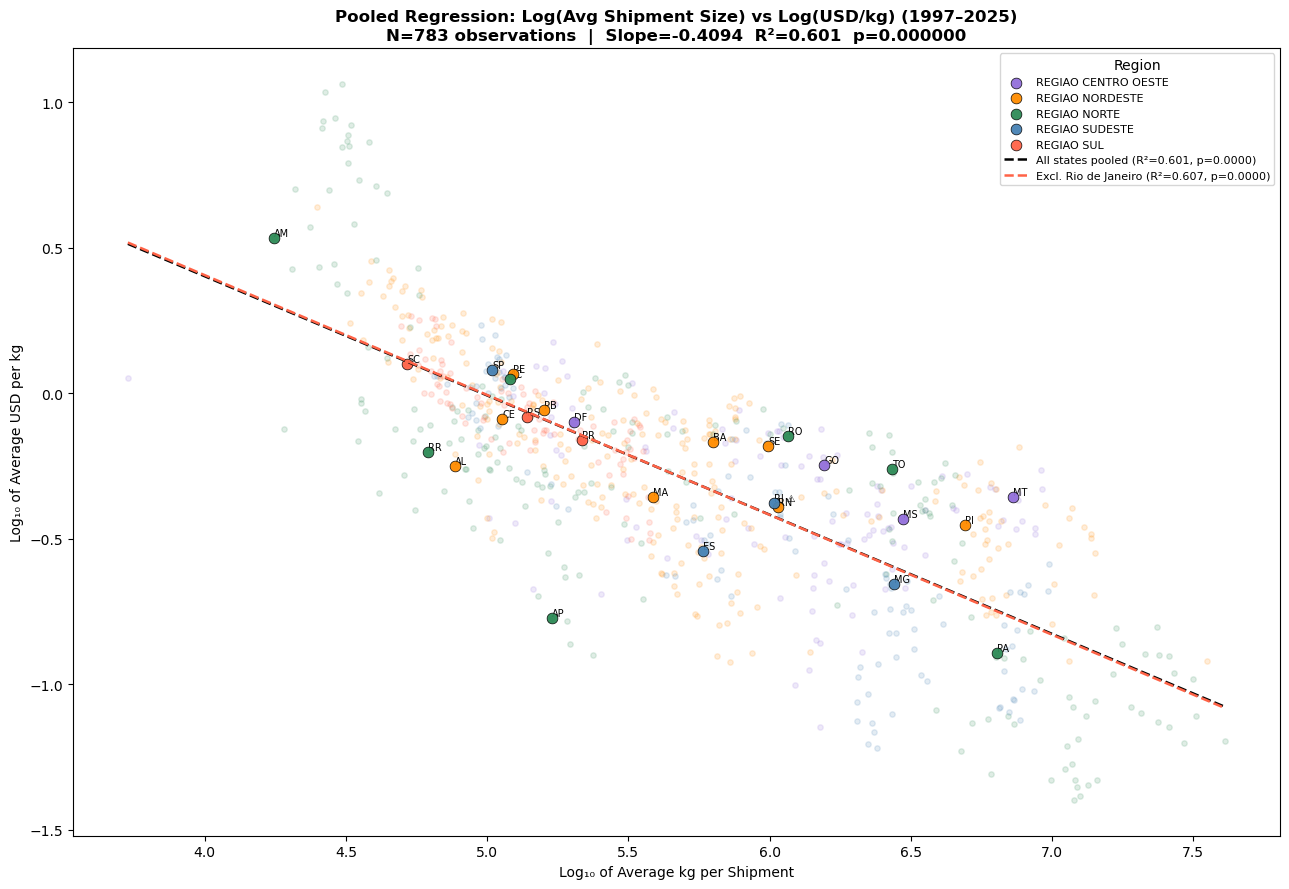


Pooled Regression Results — Log-Log (1997–2025)

  All states (n=783):
    Slope:      -0.4094
    Intercept:  2.0396
    R²:         0.6013
    p-value:    0.000000
    Std Error:  0.0119

  Excluding Rio de Janeiro (n=754):
    Slope:      -0.4117
    Intercept:  2.0525
    R²:         0.6073
    p-value:    0.000000
    Std Error:  0.0121


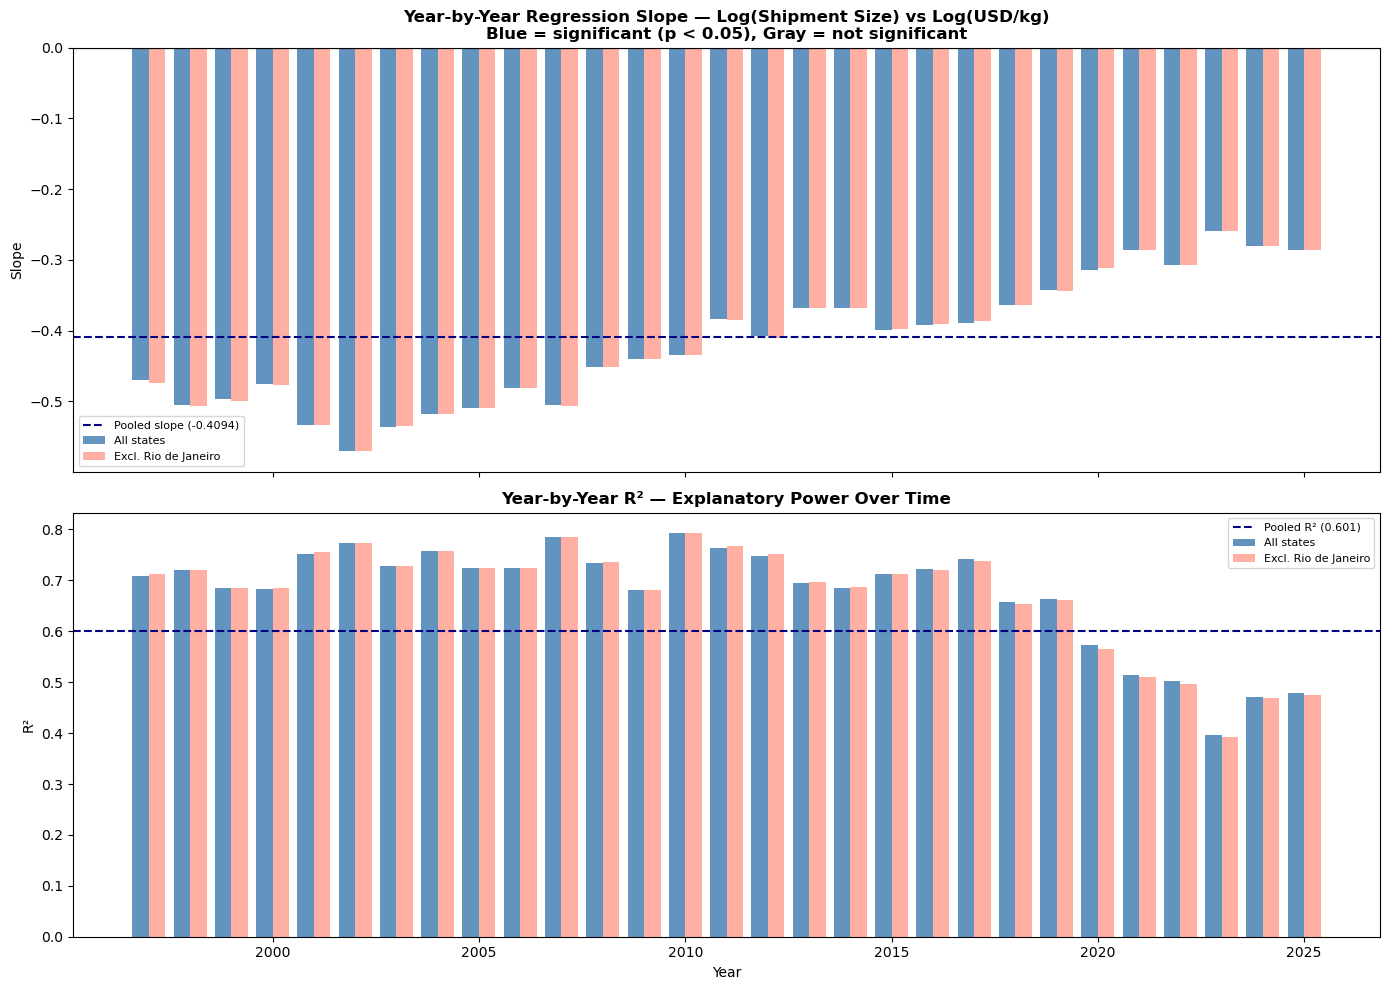


Year-by-Year Regression Results:
 year  slope_full  r2_full  p_full  slope_excl_rj  r2_excl_rj  p_excl_rj  n
 1997     -0.4701   0.7087  0.0000        -0.4736      0.7117     0.0000 27
 1998     -0.5043   0.7197  0.0000        -0.5067      0.7208     0.0000 27
 1999     -0.4971   0.6842  0.0000        -0.4996      0.6854     0.0000 27
 2000     -0.4757   0.6832  0.0000        -0.4773      0.6853     0.0000 27
 2001     -0.5333   0.7517  0.0000        -0.5330      0.7550     0.0000 27
 2002     -0.5706   0.7735  0.0000        -0.5694      0.7743     0.0000 27
 2003     -0.5355   0.7281  0.0000        -0.5350      0.7280     0.0000 27
 2004     -0.5182   0.7586  0.0000        -0.5181      0.7587     0.0000 27
 2005     -0.5099   0.7234  0.0000        -0.5099      0.7234     0.0000 27
 2006     -0.4807   0.7243  0.0000        -0.4807      0.7244     0.0000 27
 2007     -0.5054   0.7855  0.0000        -0.5058      0.7862     0.0000 27
 2008     -0.4514   0.7344  0.0000        -0.4518     

In [15]:
## Regression: Log(Avg Shipment Size) vs Log(USD/kg) — All Years (1997–MAX_YEAR)
## Log-log specification removes currency scale effects and makes year-by-year
## slopes directly comparable across the full 1997–2025 period
## Query: avg shipment size and value density for all years
query_shipsize_all = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           COUNT(*) AS shipment_count
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND e."KG_LIQUIDO" > 0
    AND u.nome_regiao NOT IN (
    'REGIAO NAO DECLARADA',
    'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA',
    'REEXPORTACAO'
)
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, exports_usd DESC
"""

df_shipsize_all = pd.read_sql(query_shipsize_all, engine)
df_shipsize_all['avg_kg_per_shipment'] = df_shipsize_all['total_kg']    / df_shipsize_all['shipment_count']
df_shipsize_all['avg_usd_per_kg']      = df_shipsize_all['exports_usd'] / df_shipsize_all['total_kg']
df_shipsize_all['exports_usd_bn']      = df_shipsize_all['exports_usd'] / 1e9

## Log transformations — clip to avoid log(0) errors
df_shipsize_all['log_avg_kg']          = np.log10(df_shipsize_all['avg_kg_per_shipment'].clip(lower=0.001))
df_shipsize_all['log_avg_usd_per_kg']  = np.log10(df_shipsize_all['avg_usd_per_kg'].clip(lower=0.001))

## Clean
df_shipsize_all = df_shipsize_all.merge(df_state[['uf', 'region']], on='uf', how='left')
df_shipsize_all = df_shipsize_all[~df_shipsize_all['region'].isin(['REGIAO NAO DECLARADA'])]
df_shipsize_all = df_shipsize_all[~df_shipsize_all['state'].isin(['Não Declarada', 'Exterior'])]
df_shipsize_all = df_shipsize_all[df_shipsize_all['avg_kg_per_shipment'] > 0]

## ---- Part 1: Pooled regression ----
df_pool_full = df_shipsize_all.copy()
df_pool_excl = df_shipsize_all[df_shipsize_all['state'] != 'Rio de Janeiro']

slope_f, intercept_f, r_value_f, p_value_f, std_err_f = stats.linregress(
    df_pool_full['log_avg_kg'], df_pool_full['log_avg_usd_per_kg']
)
slope_e, intercept_e, r_value_e, p_value_e, std_err_e = stats.linregress(
    df_pool_excl['log_avg_kg'], df_pool_excl['log_avg_usd_per_kg']
)
r_squared_f = r_value_f ** 2
r_squared_e = r_value_e ** 2

x_line = np.linspace(df_pool_full['log_avg_kg'].min(),
                     df_pool_full['log_avg_kg'].max(), 100)
y_line_f = slope_f * x_line + intercept_f
y_line_e = slope_e * x_line + intercept_e

region_colors_reg2 = {
    r: c for r, c in zip(
        df_shipsize_all['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

## Pooled scatter — all years semi-transparent, MAX_YEAR labelled
fig, ax = plt.subplots(figsize=(13, 9))
for region, group in df_pool_full.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(group['log_avg_kg'], group['log_avg_usd_per_kg'],
               color=color, s=15, alpha=0.15, zorder=2)

df_latest = df_pool_full[df_pool_full['year'] == MAX_YEAR]
for region, group in df_latest.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(group['log_avg_kg'], group['log_avg_usd_per_kg'],
               color=color, s=60, alpha=0.95, zorder=4,
               edgecolors='black', linewidths=0.5, label=region)
    for _, row in group.iterrows():
        label = f"{row['uf']} ⚠" if row['state'] == 'Rio de Janeiro' else row['uf']
        ax.annotate(label, (row['log_avg_kg'], row['log_avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.plot(x_line, y_line_f, color='black', linewidth=1.8, linestyle='--',
        label=f'All states pooled (R²={r_squared_f:.3f}, p={p_value_f:.4f})',
        zorder=5)
ax.plot(x_line, y_line_e, color='tomato', linewidth=1.8, linestyle='--',
        label=f'Excl. Rio de Janeiro (R²={r_squared_e:.3f}, p={p_value_e:.4f})',
        zorder=5)

ax.set_title(f'Pooled Regression: Log(Avg Shipment Size) vs Log(USD/kg) '
             f'(1997–{MAX_YEAR})\n'
             f'N={len(df_pool_full)} observations  |  '
             f'Slope={slope_f:.4f}  R²={r_squared_f:.3f}  p={p_value_f:.6f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Log₁₀ of Average kg per Shipment')
ax.set_ylabel('Log₁₀ of Average USD per kg')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b8_regression_pooled.png', dpi=150)
plt.show()

print(f"\nPooled Regression Results — Log-Log (1997–{MAX_YEAR})")
print(f"\n  All states (n={len(df_pool_full)}):")
print(f"    Slope:      {slope_f:.4f}")
print(f"    Intercept:  {intercept_f:.4f}")
print(f"    R²:         {r_squared_f:.4f}")
print(f"    p-value:    {p_value_f:.6f}")
print(f"    Std Error:  {std_err_f:.4f}")
print(f"\n  Excluding Rio de Janeiro (n={len(df_pool_excl)}):")
print(f"    Slope:      {slope_e:.4f}")
print(f"    Intercept:  {intercept_e:.4f}")
print(f"    R²:         {r_squared_e:.4f}")
print(f"    p-value:    {p_value_e:.6f}")
print(f"    Std Error:  {std_err_e:.4f}")

## ---- Part 2: Year-by-year regression ----
yearly_results2 = []
for year, group in df_pool_full.groupby('year'):
    if len(group) < 5:
        continue
    s_f, i_f, r_f, p_f, se_f = stats.linregress(
        group['log_avg_kg'], group['log_avg_usd_per_kg']
    )
    group_e = group[group['state'] != 'Rio de Janeiro']
    s_e, i_e, r_e, p_e, se_e = stats.linregress(
        group_e['log_avg_kg'], group_e['log_avg_usd_per_kg']
    )
    yearly_results2.append({
        'year'         : year,
        'slope_full'   : round(s_f, 4),
        'r2_full'      : round(r_f ** 2, 4),
        'p_full'       : round(p_f, 4),
        'slope_excl_rj': round(s_e, 4),
        'r2_excl_rj'   : round(r_e ** 2, 4),
        'p_excl_rj'    : round(p_e, 4),
        'n'            : len(group)
    })

df_yearly2 = pd.DataFrame(yearly_results2)

## Plot year-by-year slope and R²
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors_sig = ['steelblue' if p < 0.05 else 'lightgray' for p in df_yearly2['p_full']]

ax1.bar(df_yearly2['year'] - 0.2, df_yearly2['slope_full'],
        width=0.4, color=colors_sig, alpha=0.85, label='All states')
ax1.bar(df_yearly2['year'] + 0.2, df_yearly2['slope_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. Rio de Janeiro')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axhline(y=slope_f, color='navy', linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_f:.4f})')
ax1.set_title('Year-by-Year Regression Slope — Log(Shipment Size) vs Log(USD/kg)\n'
              'Blue = significant (p < 0.05), Gray = not significant',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope')
ax1.legend(fontsize=8)

ax2.bar(df_yearly2['year'] - 0.2, df_yearly2['r2_full'],
        width=0.4, color=colors_sig, alpha=0.85, label='All states')
ax2.bar(df_yearly2['year'] + 0.2, df_yearly2['r2_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. Rio de Janeiro')
ax2.axhline(y=r_squared_f, color='navy', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r_squared_f:.3f})')
ax2.set_title('Year-by-Year R² — Explanatory Power Over Time',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output_2b8_regression_yearly.png', dpi=150)
plt.show()

print(f"\nYear-by-Year Regression Results:")
print(df_yearly2.to_string(index=False))

sig_years2 = df_yearly2[df_yearly2['p_full'] < 0.05]
print(f"\n  Significant years (p < 0.05): {len(sig_years2)} of {len(df_yearly2)}")
print(f"  Average slope (all years):        {df_yearly2['slope_full'].mean():.4f}")
print(f"  Average slope (significant only): {sig_years2['slope_full'].mean():.4f}")
print(f"  Average R² (all years):           {df_yearly2['r2_full'].mean():.4f}")
print(f"  Average R² (significant only):    {sig_years2['r2_full'].mean():.4f}")

### Model Summary

**R² = 0.0.6013** 

The physical characteristics of what states export — the weight-to-value ratio embedded in their commodity mix — is the single most powerful predictor of export profile available in this dataset. 

Across 27 states and 29 years, approximately 60% of the variation in export value density (USD/kg) is explained by a single variable: average shipment size (kg per shipment) - how heavy their average shipment is. 

This relationship reflects a structural feature of Brazil’s export profile: shipment size acts as a physical proxy for product composition. 
* States specialized in bulk commodities ship large volumes with low value density;
* States specialized in manufactured goods export smaller, higher-value consignments.

Importantly, shipment size is not a causal driver of value density, but rather a manifestation of the underlying goods being traded.

---

## Rio de Janeiro - Not a Physical outlier

**Rio de Janeiro is genuinely not an outlier in this specification.** Excluding it changes R² by only 0.006 (0.6013 → 0.6073) and the slope by only 0.0023. This is the cleanest confirmation yet that Rio de Janeiro's anomaly is operational (high frequency despite high concentration) rather than physical (its shipment size correctly predicts its value density).

| Metric | All States (n=783) | Excl. Rio de Janeiro (n=754) |
|---|---|---|
| Slope | -0.4094 | -0.4117 |
| Intercept | 2.0396 | 2.0525 |
| R² | 0.6013 | 0.6073 |
| p-value | < 0.000001 | < 0.000001 |
| Std Error | 0.0119 | 0.0121 |
| N | 783 | 754 |

**Result: Statistically significant negative relationship across all 29 years**

---

## Interpretation of the Elasticity; The Log-Log Specification

Running the regression as log(avg kg per shipment) vs log(USD/kg) rather than log(kg) vs raw(USD/kg) produces slopes that are directly interpretable as elasticities and comparable across years regardless of currency fluctuations. The slope of -0.4094 means that a **1% increase in average shipment size is associated with a 0.409% decrease in export value density** — a near-half elasticity that holds consistently across the full 1997–2025 period.

This elasticity formalizes the quadrant structure observed in the logistics classification: 
* Bulk commodity states occupy the high-weight/low-value region;
* Industrial states occupy the inverse.

In practical terms — moving from a state with 100,000 kg average shipments to one with 1,000,000 kg average shipments (a 10x or 1,000% increase) the model predicts a 48.5% decrease in USD/kg. 

The actual data broadly confirms this: São Paulo (94k kg, \\$1.20/kg) vs Mato Grosso (7,276k kg, \\$0.44/kg) — a 77x increase in shipment size corresponds to a 63% decrease in value density, somewhat steeper than the model predicts, consistent with Mato Grosso sitting slightly below the regression line.

---

## COVID-19: A Different Pattern from the Frequency-HHI Regression

The contrast between the two regressions during COVID is analytically important:

| Year | Freq-HHI R² | Freq-HHI significant | Size-Density R² | Size-Density significant |
|---|---|---|---|---|
| 2019 | 0.154 | Yes (barely) | 0.664 | Yes |
| 2020 | 0.098 | **No** | 0.574 | Yes |
| 2021 | 0.071 | **No** | 0.515 | Yes |
| 2022 | 0.136 | **No** | 0.503 | Yes |
| 2023 | 0.130 | **No** | 0.396 | Yes |
| 2024 | 0.168 | Yes | 0.470 | Yes |
| 2025 | 0.192 | Yes | 0.479 | Yes |

The frequency-HHI relationship **broke completely** during COVID (four non-significant years). The shipment size-value density relationship **weakened but held** — R² fell from 0.664 to 0.479 but remained statistically significant throughout.

This reveals that COVID-19 disrupted operational trade patterns (frequency) while leaving physical trade characteristics (shipment composition) relatively intact. This is consistent with the Step 1 finding that Brazil's goods trade volumes were resilient during COVID-19.

The physical dimension of trade (what states ship and how valuable it is per kg) is a substantially more stable and powerful structural signal than the operational dimension (how often they transact relative to their product concentration). In other words, shipment size is not a causal driver but a physical manifestation of underlying product composition. The 60% pooled R² and 100% year significance rate make the shipment size-value density regression the most robust finding in Step 2b.

---

## Conclusion

The log-log regression of average shipment size vs export value density is the most statistically powerful relationship identified in Step 2b. It is significant in every single year from 1997 to 2025 with an average R² of 0.6749 — meaning that across nearly three decades, how heavy a state's average export shipment is explains approximately 67% of the variation in how much value that state generates per kg of goods exported.

The structural story this tells is simple and powerful: **Brazil's export value creation is physically encoded in its shipment profiles.** States that have transitioned to lighter, higher-value exports (São Paulo, Santa Catarina, Amazonas) generate dramatically more value per kg than states locked into heavy bulk commodity logistics (Mato Grosso, Pará, Minas Gerais). This divide has persisted for nearly 30 years and, while weakening since 2019, remains the dominant structural feature of Brazil's state-level export competitiveness.

> ⚠️ *The post-2019 weakening of the relationship (R² declining from ~0.71 to ~0.48) is the most important open question from this regression. It predates COVID-19 and has not recovered to pre-2019 levels. Whether this reflects genuine convergence between commodity and industrial state export profiles — or a measurement artefact of changing trade recording practices — requires investigation beyond what trade flow data alone can provide.*

---
---

## Step 2b — Conclusion

### Overview

Step 2b extends the state-level trade analysis from Step 2 into structural competitiveness metrics — moving beyond what states trade and with whom, toward how competitive they are, how concentrated their product base is, and what their physical export profile reveals about their position in global value chains.

Six analytical lenses were applied across all 27 Brazilian states:
1. Revealed Comparative Advantage (RCA) — sector-level competitive strengths
2. Export Specialisation Index (KSI) — deviation from the national export mix
3. Product Concentration Index (HHI) — within-state sector concentration
4. Export Frequency — number of transactions as an operational proxy
5. Shipment Size and Value Density — physical export profile (kg and USD/kg)
6. Regression Analysis — two panel regressions covering 1997–2025 (n=783 each): Log(frequency) vs HHI and Log(shipment size) vs Log(USD/kg)

---

### Key Findings

**Finding 1 — The Commodity-Industrial Divide is Brazil's Defining Export Structure**
Every metric in Step 2b — RCA, KSI, HHI, frequency, shipment size and value density — converges on the same structural divide. Brazilian states fall into two broad categories that are consistent across all indicators:

- **Industrial / Diversified states:** São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Bahia, Minas Gerais (partial), Amazonas (Free Trade Zone driven)
- **Commodity / Concentrated states:** Mato Grosso, Pará, Piauí, Alagoas, Rio de Janeiro, Espírito Santo, Mato Grosso do Sul, Tocantins

The Sul region is the only region where every state falls in the industrial category across all metrics. The Centro-Oeste is the only region where every state falls in the commodity category. All other regions contain states from both sides of the divide.

The RCA analysis identifies the clearest cases of genuine structural competitive advantage where high RCA coincides with material export value: Rio de Janeiro in mineral fuels (\\$40.79bn, RCA 5.30), Pará in ores (\\$15.73bn, RCA 6.42), Minas Gerais in coffee (\\$11.29bn, RCA 5.45), São Paulo in aerospace (\\$4.54bn, RCA 4.65), and Mato Grosso in soybeans ($13.17bn, RCA 3.39). Notably, all of these are commodity or agro-processed sectors. The KSI and HHI results confirm the same divide from different angles — the Sul region produces the most nationally representative export basket (average KSI ~1.01) and the lowest product concentration of any region (all three states below HHI 0.154). The logistics profile classification draws these findings together: the Sul region is uniformly High-Value Industrial; the Centro-Oeste is uniformly Bulk Commodity.

This divide is quantified by the official MDIC product classification (cell 2.13). At the national level, Brazil's export composition has undergone a complete structural reversal since 1997 — from 56.0% manufactured goods to 28.7%, and from 27.7% primary commodities to 58.2%. The commodity-industrial divide identified across every Step 2b metric is not a statistical artefact — it reflects a genuine 28-year structural shift in which commodity export growth outpaced industrial export growth at every stage of the period.

---

**Finding 2 — Rio de Janeiro is Brazil's Most Structurally Anomalous Export State**
Rio de Janeiro appears as an outlier in more metrics than any other state:

- Highest HHI in Brazil (0.699) — the most concentrated large exporter
- Highest KSI among large exporters (1.363) — most specialised relative to national mix
- Primary outlier in the frequency-HHI regression — high transaction frequency despite extreme product concentration
- Consistent with the shipment size-value density model — excluding Rio de Janeiro changes R² by only 0.006, confirming its anomaly is operational rather than physical
- RCA profile dominated by a single sector — mineral fuels (RCA 5.18, \\$40.79bn)

The oil and gas sector creates a unique export identity that does not map cleanly onto either the industrial or commodity classification. Rio de Janeiro has the operational characteristics of an industrial state (125K transactions, established port infrastructure) but the product concentration of a resource extraction economy.

> ⚠️ *Rio de Janeiro's export concentration in oil and gas represents the single largest commodity risk in Brazil's state-level trade profile. Energy transition risk and commodity price volatility would disproportionately impact a state that generates $48.98bn in exports through a single SH2 chapter.*

---

**Finding 3 — The Sul Region is Brazil's Most Structurally Coherent Export Region**
Across every metric in Step 2b, the three Sul states — Paraná, Rio Grande do Sul and Santa Catarina — form a consistently distinct cluster:

| Metric | Paraná | Rio Grande do Sul | Santa Catarina |
|---|---|---|---|
| HHI | 0.099 | 0.080 | 0.154 |
| KSI | 0.846 | 0.893 | 1.278 |
| Avg USD/kg | \\$0.69 | \\$0.83 | \\$1.26 |
| Frequency | 168k | 200k | 199k |
| Logistics profile | High-Value Industrial | High-Value Industrial | High-Value Industrial |

All three states are high-frequency, low-HHI, above-median value density exporters classified in the High-Value Industrial quadrant. No other region achieves this level of internal consistency across all indicators. The Sul region collectively defines the industrial export pole of Brazil.

Santa Catarina's KSI of 1.278 is the only outlier within the group — it deviates from the national export mix more than its Sul neighbours, driven by its textile and vessel manufacturing RCA profile. Its low HHI (0.154) and high value density ($1.26/kg) confirm it belongs structurally in the industrial tier despite the specialisation deviation.

---

**Finding 4 — Amazonas is the Most Structurally Distinct State in Brazil**
Amazonas generates \\$3.43/kg — the highest export value density in Brazil, 2.7 times higher than second-place Santa Catarina (\\$1.26/kg) and 26 times higher than Pará (\\$0.13/kg). It is the only Norte state classified as High-Value Industrial and sits furthest above the regression line in the shipment size-value density model.

The Zona Franca de Manaus creates an export identity entirely disconnected from the geographic and natural resource context of the Norte region. Electronics, motorcycles and manufactured consumer goods generate a logistics profile (16,077 kg average shipment) that has no equivalent among Brazilian states outside the Sul and parts of the Southeast.

> ⚠️ *Amazonas's export competitiveness is structurally dependent on the continuation of the Zona Franca de Manaus regime. Any policy change to the Free Trade Zone would fundamentally alter the state's position across all competitiveness metrics.*

---

**Finding 5 — The Regression Analyses Reveal a Two-Dimensional State Classification**
Two panel regressions were run across Step 2b, both covering 1997–2025 (n=783 state-year observations):

**Regression 1 — Log(Shipment Frequency) vs HHI:**
- Pooled R² = 0.358, slope = -0.1175, significant in 25 of 29 years
- States with higher export frequency tend toward lower product concentration (diversified portfolio)
- Rio de Janeiro is the primary outlier — high frequency despite extreme concentration
- Relationship weakened post-2015 and broke down during COVID-19 (2020–2023)

**Regression 2 — Log(Avg Shipment Size) vs Log(USD/kg) — log-log specification:**
- Pooled R² = 0.601, elasticity = -0.4094 (a 1% increase in avg shipment size → 0.409% decrease in USD/kg)
- Significant in 29 of 29 years — never breaks down including during COVID-19
- Rio de Janeiro is not an outlier — crude oil fits the model
- Amazonas is the primary outlier — anomalously high value density for its shipment size

| Regression | Pooled R² | Significant years | Primary outlier |
|---|---|---|---|
| Freq vs HHI | 0.358 | 25 of 29 | Rio de Janeiro |
| Size vs USD/kg (log-log) | 0.601 | 29 of 29 | Amazonas |

Physical shipment characteristics explain more variation in export structure than operational frequency patterns, and do so more consistently across time. A state's position above or below both regression lines simultaneously defines a two-dimensional competitive profile:

| Position | Freq-HHI | Size-Density | Interpretation |
|---|---|---|---|
| Above both lines | Higher freq than HHI predicts | Higher value than size predicts | Industrial overperformer |
| Below both lines | Lower freq than HHI predicts | Lower value than size predicts | Commodity underperformer |
| Above Freq-HHI, below Size-Density | Operationally active, physically heavy | Mixed — processing with bulk logistics |
| Below Freq-HHI, above Size-Density | Infrequent but high-value | Niche high-value or specialised manufacturer |

---

**Finding 6 — A Post-2019 Structural Weakening Appears in Both Regressions**
Both regressions show simultaneous weakening beginning around 2017–2018 that predates COVID-19 and has not fully recovered by 2025.

The frequency-HHI slope fell from approximately -0.138 (1997–2015 average) to approximately -0.089 (2016–2025 average) and lost statistical significance entirely during 2020–2023. The size-density R² declined from ~0.84 (2002–2008 peak) to ~0.48 (2023–2025), weakening gradually but remaining significant in all 29 years.

The COVID divergence between the two regressions is the most analytically revealing finding in Step 2b:

| Year | Freq-HHI R² | Freq-HHI significant | Size-Density R² | Size-Density significant |
|---|---|---|---|---|
| 2019 | 0.154 | Yes (barely) | 0.664 | Yes |
| 2020 | 0.098 | **No** | 0.574 | Yes |
| 2021 | 0.071 | **No** | 0.515 | Yes |
| 2022 | 0.136 | **No** | 0.503 | Yes |
| 2023 | 0.130 | **No** | 0.396 | Yes |
| 2024 | 0.168 | Yes | 0.470 | Yes |
| 2025 | 0.192 | Yes | 0.479 | Yes |

COVID disrupted the operational dimension of trade completely while the physical dimension weakened but held — states continued shipping the same physical profile of goods even when transaction frequency was disrupted. This is consistent with the Step 1 finding that Brazil's goods trade volumes were resilient during COVID-19.

> ⚠️ *The post-2018 weakening appears simultaneously in both regressions, predates COVID-19, and has not recovered to pre-2018 levels in either specification. Production data, port infrastructure investment and agricultural land use change data would be needed to identify the mechanism.*

---

**Finding 7 — The Nordeste is Brazil's Most Internally Heterogeneous Region**
The Nordeste contains states across all four logistics profile quadrants simultaneously — a finding not replicated in any other region:

- **Bulk Commodity:** Piauí (HHI 0.688, \\$0.35/kg), Rio Grande do Norte
- **High-Value Industrial:** Pernambuco (\\$1.17/kg), Ceará (\\$0.82/kg)
- **Large High-Value:** Bahia (\\$0.68/kg, HHI 0.106), Sergipe
- **Small Low-Value:** Alagoas (HHI 0.559), Maranhão

Pernambuco and Alagoas — neighbouring states — sit at opposite ends of the value density ranking (\\$1.17/kg vs \\$0.56/kg). Any Nordeste-level generalisation about Brazil's export competitiveness will mask this internal heterogeneity. The Northeast also has the smallest absolute export base of any region ($25.25bn), which limits the structural weight of its regional averages.

---

**Finding 8 — High RCA Does Not Imply High Export Value**
The RCA analysis reveals a systematic pattern: the highest RCA values are frequently found in sectors with negligible export volumes. Paraíba's footwear (RCA 100.97, \\$0.05bn), Roraima's cereal preparations (RCA 81.55, \\$0.02bn), and Santa Catarina's textile cluster (four sectors above RCA 13, all below \\$0.06bn) are the most extreme cases. This is partly a mathematical artefact — when national market shares in a sector are very small, even a modest state presence generates a high ratio. RCA values above 10 with export values below \\$0.1bn should be treated with caution.

The most economically significant RCA findings are those combining high RCA with material export value: Minas Gerais coffee (RCA 5.48, \\$11.29bn), Pará iron ore (RCA 6.45, \\$15.73bn), Mato Grosso soybeans (RCA 3.40, \\$13.17bn) and São Paulo aerospace (RCA 4.53, \\$4.54bn). The KSI carries a parallel limitation: a low KSI does not indicate industrial sophistication — it indicates similarity to the national average, which is now 58.2% primary commodities.

---

### Limitations

**Frequency as proxy:** Row count per state is a proxy for shipment count, not an official transaction register. Liquid bulk commodities (oil, liquid chemicals) may generate transaction records at a different granularity than solid bulk or containerised goods.

**RCA at SH2 level:** Calculating RCA at the 2-digit sector level aggregates significant product diversity within each chapter. SH4 or NCM-level RCA would provide more precise competitive advantage identification but at substantially higher computational cost.

**Single year for most metrics:** KSI, HHI, frequency and shipment size were calculated for 2025 only. Both regressions were extended to the full 1997–2025 panel (n=783) which substantially strengthens the regression findings, but the underlying indicator values (HHI, KSI, USD/kg) remain single-year snapshots. Multi-year panels for all indicators would provide more robust estimates.

---

### Business Implications

1. **Rio de Janeiro — single-sector concentration risk.** ~\\$48.98bn in exports is concentrated in a single SH2 chapter (mineral fuels, RCA 5.18). Any business with supply chain, logistics, financial, or counterparty exposure to Rio de Janeiro’s export base is highly exposed to commodity price cycles and energy transition risk, with limited sectoral diversification.

2. **Amazonas — policy-dependent competitiveness.** The state’s export profile — including the highest value density in Brazil at \\$3.43/kg — is closely tied to the Zona Franca de Manaus regime. Investment or operational decisions dependent on Amazonas’s current competitive position therefore carry structural regulatory risk.

3. **Sul region — most stable operating environment.** Paraná, Rio Grande do Sul, and Santa Catarina are the only region where all states are consistently classified as High-Value Industrial across key metrics, with relatively low product concentration (HHI 0.080–0.154), high export frequency, and steady long-run CAGRs (+4.5% to +5.8%). This suggests the Sul region represents the most predictable export counterparty environment in Brazil.

4. **Bulk commodity states — supply chain cycle exposure.** Mato Grosso, Pará, Mato Grosso do Sul, and Goiás are consistently classified as Bulk Commodity exporters. Supply chains reliant on these states as input sources are therefore exposed to commodity price cycles, reflected in their growth volatility — for example, Mato Grosso peaked in 2022, while Pará remains ~$5bn below its 2021 peak.

5. **Northeast — state-level differentiation required.** The Nordeste includes states across multiple logistics profile categories simultaneously. Regional-level assessments are therefore likely to obscure meaningful differences — for example, Pernambuco (\\$1.17/kg, High-Value Industrial) and Alagoas ($0.56/kg, Small Low-Value) require fundamentally different counterparty assessments despite geographic proximity.

---

### What Comes Next

**Step 2c — Regression Analysis (Deep Dive)**
The regression relationships introduced in step 2b — frequency vs HHI and shipment size vs USD/kg — will be explored in further detail, including checks across multiple specifications, the COVID-19 structural break and the outlier behaviour of Amazonas and Rio de Janeiro across both models.

**Municipality-Level Hotspots**
Disaggregating the state-level findings to the municipality level to identify the specific cities and industrial clusters driving each state's export profile.

**Product Complexity and Diversification**
NCM-level product analysis to explain the KSI and HHI findings — particularly Ceará's anomalous KSI (1.59) given the absence of an obvious single-commodity anchor, Pernambuco's high value density, and the RCA artefact problem in small states.

**Logistics Infrastructure**
Mapping the logistics profile classification against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.